# Week 7: Behavioral Authentication Defender Pipeline on Balabit
This notebook extends the Week 6 defender pipeline with real attacker data, now fully integrated: WindMouse and SapiAgent bypass results (both scored across all four tiers), an upgraded vulnerability classifier trained on real bypass rates, anomaly detection tested against real synthetic attacks, and a threshold-floor fix for a critical calibration failure. All attacker-dependent analyses that were previously placeholders are now backed by real data from the attacker side.

**Evaluation design:**

Binary authentication: 1 = genuine enrolled user, 0 = imposter

Per-user models: each user is evaluated separately

Window size: 128 time steps

Fair protocol: same users, windows, fit/calibration/test split, seeds, threshold policies, and metrics across tiers

Threshold policies: default 0.5, calibration EER threshold, calibration low-FAR threshold, and a floored low-FAR threshold (new this week - prevents the threshold from collapsing to near-zero)

**Model tiers:**

*   T0: rule/threshold sanity baseline
*   T1: Logistic Regression, SVM, k-NN, and Decision Tree
*   T2: Random Forest, ExtraTrees, Gradient Boosting, and XGBoost
*   T3: 1D-CNN sequence baseline

**Reported metrics** include TAR, FAR, FRR, F1, AUC, EER, and per-user vulnerability.

**New this week:**
- **Threshold floor policy** - fixes a reproducible calibration failure (one user's CNN defender collapsed to a near-zero threshold across all 3 seeds despite perfect clean AUC) without affecting any other user/model combination.
- **Vulnerability Classifier v2** - upgraded from clean-metrics-only to using real bypass rate as the target label (binary: bypassed at all vs. never), with a proper train/test confusion matrix and feature importance.
- **Anomaly Detection v2** - tested against real SapiAgent AND WindMouse attack sessions instead of just human imposters; caught 100% of the SapiAgent sessions that got past the primary gatekeeper, with a direct catch-rate comparison against WindMouse.
- **Robustness Drop (real data)** - direct comparison of clean FAR vs. real attack bypass rate. Headline finding: clean FAR does not predict robustness - several models with excellent clean FAR were completely bypassed by SapiAgent.
- **WindMouse scored across all four tiers** (not just T3 as before), enabling a direct, like-for-like comparison against SapiAgent for the first time - see the Attacker Comparison section near the end.


#Setting Up the Environment

In [ ]:
# Mounts your Google Drive so files can be read/saved from /content/drive/MyDrive/.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
for name in ["sapiagent_sessions", "windmouse_sessions"]:
    for s in [0, 1, 2]:
        path = f"/content/drive/MyDrive/handoff/{name}/seed{s}"
        print(name, s, len(os.listdir(path)) if os.path.exists(path) else "MISSING")

sapiagent_sessions 0 20
sapiagent_sessions 1 20
sapiagent_sessions 2 20
windmouse_sessions 0 20
windmouse_sessions 1 20
windmouse_sessions 2 20


In [ ]:
# Sets random seeds for TensorFlow/NumPy/Python for reproducibility across runs.
import tensorflow as tf, numpy as np, random;
#print(tf.__version__)
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# Part 1 Get the Data

In [ ]:
!git clone https://github.com/balabit/Mouse-Dynamics-Challenge

Cloning into 'Mouse-Dynamics-Challenge'...
remote: Enumerating objects: 1711, done.
remote: Total 1711 (delta 0), reused 0 (delta 0), pack-reused 1711 (from 1)
Receiving objects: 100% (1711/1711), 42.60 MiB | 14.46 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Updating files: 100% (1678/1678), done.


#Part 2 Loading the Data

In [ ]:
# Defines load_session(): reads one raw Balabit session CSV and standardizes its columns.
import pandas as pd

def load_session(path):
  df = pd.read_csv(path, sep=',')
  df = df.sort_values('record timestamp')
  df = df.dropna(subset=['x', 'y'])
  return df

In [ ]:
# Loads all training sessions into `all_sessions` (list of dataframes, one per session).
import os

all_sessions = []

training_path = '/content/Mouse-Dynamics-Challenge/training_files'

for user in sorted(os.listdir(training_path)):
    user_path = os.path.join(training_path, user)
    if not os.path.isdir(user_path):
        continue
    for session_file in sorted(os.listdir(user_path)):
        session_path = os.path.join(user_path, session_file)
        df = load_session(session_path)
        df['user'] = user
        df['session'] = session_file
        df['label'] = 0
        all_sessions.append(df)

print(f"Loaded {len(all_sessions)} sessions")

Loaded 65 sessions


In [ ]:
# Check which users loaded and how many sessions each has
from collections import Counter
user_counts = Counter(df['user'].iloc[0] for df in all_sessions)
print(user_counts)

Counter({'user12': 7, 'user20': 7, 'user21': 7, 'user29': 7, 'user7': 7, 'user9': 7, 'user15': 6, 'user16': 6, 'user23': 6, 'user35': 5})


In [ ]:
# Loads the public test-set labels (genuine/imposter) for the Balabit test sessions.
import pandas as pd

# Load labels
labels_path = '/content/Mouse-Dynamics-Challenge/public_labels.csv'
labels_df = pd.read_csv(labels_path, sep=',')
print(labels_df.head())
print(labels_df.shape)

             filename  is_illegal
0  session_0003960194           1
1  session_0005840196           0
2  session_0025450757           0
3  session_0029922803           0
4  session_0064281061           1
(816, 2)


In [ ]:
# Loads all test sessions into `test_sessions`, matched against the labels above.
test_sessions = []

test_path = '/content/Mouse-Dynamics-Challenge/test_files'

for user in sorted(os.listdir(test_path)):
    user_path = os.path.join(test_path, user)
    if not os.path.isdir(user_path):
        continue
    for session_file in sorted(os.listdir(user_path)):
        session_path = os.path.join(user_path, session_file)

        # look up label from public_labels.csv
        match = labels_df[labels_df['filename'] == session_file]
        if match.empty:
            continue  # skip sessions without a public label

        label = match.iloc[0]['is_illegal']
        df = load_session(session_path)
        df['user'] = user
        df['session'] = session_file
        df['label'] = label
        test_sessions.append(df)

print(f"Loaded {len(test_sessions)} labeled test sessions")

# sanity check label distribution
import collections
label_counts = collections.Counter(df['label'].iloc[0] for df in test_sessions)
print(label_counts)

Loaded 816 labeled test sessions
Counter({np.int64(0): 411, np.int64(1): 405})


#Part 3: Feature Extraction

In [ ]:
# extract_features(): converts raw x/y/timestamp into velocity, acceleration, jerk, angle, curvature, pause.
def extract_features(df):
    df = df.copy().reset_index(drop=True)

    dt = df['record timestamp'].diff().fillna(0)
    dt = dt.replace(0, 1e-6)

    dx = df['x'].diff().fillna(0)
    dy = df['y'].diff().fillna(0)
    dist = np.sqrt(dx**2 + dy**2)
    dist_safe = dist.replace(0, 1e-6)

    vx = dx / dt
    vy = dy / dt
    velocity = dist / dt
    acceleration = velocity.diff().fillna(0) / dt
    jerk = acceleration.diff().fillna(0) / dt
    angle = np.arctan2(dy, dx)
    curvature = angle.diff().fillna(0) / dist_safe
    pause = (dt > 0.1).astype(int)

    result = pd.DataFrame({
        'vx': vx, 'vy': vy, 'velocity': velocity,
        'acceleration': acceleration, 'jerk': jerk,
        'angle': angle, 'curvature': curvature, 'pause': pause
    })

    result = result.replace([np.inf, -np.inf], np.nan).fillna(0)

    # hard absolute caps based on realistic mouse movement
    result['vx'] = result['vx'].clip(-5000, 5000)
    result['vy'] = result['vy'].clip(-5000, 5000)
    result['velocity'] = result['velocity'].clip(0, 5000)
    result['acceleration'] = result['acceleration'].clip(-1e6, 1e6)
    result['jerk'] = result['jerk'].clip(-1e8, 1e8)
    result['curvature'] = result['curvature'].clip(-100, 100)

    return result

sample = extract_features(all_sessions[0])
print(sample.describe())

                 vx            vy      velocity    acceleration          jerk  \
count  30287.000000  30287.000000  30287.000000    30287.000000  3.028700e+04   
mean     -11.390592    -25.807947   1080.070007    -1006.597158  9.518941e+06   
std     1993.430982   1919.032255   1804.400489   544462.863486  6.248180e+07   
min    -5000.000000  -5000.000000      0.000000 -1000000.000000 -1.000000e+08   
25%      -88.170510    -53.571433     16.692370    -2333.700547 -1.450546e+04   
50%        0.000000      0.000000    149.813532       -2.233178  2.609899e+03   
75%       57.692258     40.322576    905.305089     2047.387828  4.467128e+07   
max     5000.000000   5000.000000   5000.000000  1000000.000000  1.000000e+08   

              angle     curvature         pause  
count  30287.000000  30287.000000  30287.000000  
mean       0.100383      0.611298      0.780467  
std        1.818575     18.311509      0.413937  
min       -3.138438   -100.000000      0.000000  
25%       -1.525024 

#Part 4 Windowing, labels, and the splie

In [ ]:
# Defines WINDOW size (128 steps) and FEATURE_COLS; builds fixed-length windows from each session.
WINDOW = 128
FEATURE_COLS = ['vx','vy','velocity','acceleration','jerk','angle','curvature','pause']

def make_windows(session_list):
    X, y = [], []
    for df in session_list:
        feats = extract_features(df).values
        label = df['label'].iloc[0]
        n_windows = len(feats) // WINDOW       # drops leftover partial window
        for w in range(n_windows):
            chunk = feats[w*WINDOW:(w+1)*WINDOW]
            X.append(chunk)
            y.append(label)
    return np.array(X), np.array(y)

# split by session: all_sessions (label 0) + 80% of test_sessions for training
import random
random.seed(42)
shuffled = test_sessions.copy()
random.shuffle(shuffled)
split = int(0.8 * len(shuffled))

train_sessions = all_sessions + shuffled[:split]
val_sessions = shuffled[split:]

X_train, y_train = make_windows(train_sessions)
X_val, y_val = make_windows(val_sessions)

print("Train:", X_train.shape, "labels:", np.bincount(y_train.astype(int)))
print("Val:", X_val.shape, "labels:", np.bincount(y_val.astype(int)))

Train: (24464, 128, 8) labels: [21854  2610]
Val: (1756, 128, 8) labels: [1171  585]


# Fair T0-T3 Baseline Comparison

The models have different complexity by design, but the evaluation protocol is held constant. T3 uses an internal validation split for early stopping so the calibration split remains reserved for threshold selection, matching the role of calibration data in T0/T1/T2.


In [ ]:
# Core evaluation helpers: window->tabular summarization, EER/threshold-at-target-FAR, and the
# threshold_policy_rows() function that evaluates one model under all threshold policies
# (including the new floor policy). Output: no direct output, defines functions used everywhere below.
from IPython.display import display
import random as pyrandom
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False

FAIR_SEEDS = [0, 1, 2]
CALIBRATION_SIZE = 0.25
T3_VALIDATION_SIZE = 0.20
LOW_FAR_TARGET = 0.10
THRESHOLD_FLOOR = 0.05  # minimum allowed calibrated threshold
T3_EPOCHS = 20
T3_BATCH_SIZE = 64
summary_cols = ["TAR", "FAR", "FRR", "F1", "AUC", "EER"]


def windows_from_sessions(session_list, label):
    X = []
    for df in session_list:
        feats = extract_features(df).values
        n = len(feats) // WINDOW
        for w in range(n):
            X.append(feats[w*WINDOW:(w+1)*WINDOW])
    return np.array(X), np.full(len(X), label, dtype=int)


def get_user(df):
    return df['user'].iloc[0]


def get_label(df):
    return df['label'].iloc[0]


def summarize_window(window):
    window = np.asarray(window, dtype=float)
    row = {}
    for j, name in enumerate(FEATURE_COLS):
        values = window[:, j]
        values = values[np.isfinite(values)]
        if len(values) == 0:
            values = np.array([0.0])
        row[f"{name}_mean"] = float(np.mean(values))
        row[f"{name}_std"] = float(np.std(values))
        row[f"{name}_median"] = float(np.median(values))
        row[f"{name}_min"] = float(np.min(values))
        row[f"{name}_max"] = float(np.max(values))
        row[f"{name}_p25"] = float(np.percentile(values, 25))
        row[f"{name}_p75"] = float(np.percentile(values, 75))
        row[f"{name}_p90"] = float(np.percentile(values, 90))
    speed = window[:, FEATURE_COLS.index("velocity")]
    pause = window[:, FEATURE_COLS.index("pause")]
    row["path_length_approx"] = float(np.sum(np.maximum(speed, 0)))
    row["pause_rate"] = float(np.mean(pause > 0))
    row["duration_windows"] = float(window.shape[0])
    return row


def windows_to_tabular(X_windows):
    rows = [summarize_window(w) for w in X_windows]
    return pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).fillna(0.0)


def compute_eer_threshold(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return np.nan, 0.5
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    return float((fpr[idx] + fnr[idx]) / 2), float(thresholds[idx])


def threshold_for_target_far(y_true, scores, target_far=LOW_FAR_TARGET, min_threshold=None):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=float)
    candidate_thresholds = np.r_[np.unique(scores), 1.0 + 1e-9]
    if min_threshold is not None:
        candidate_thresholds = candidate_thresholds[candidate_thresholds >= min_threshold]
        if len(candidate_thresholds) == 0:
            candidate_thresholds = np.array([min_threshold])
    best_threshold, best_tar, best_far = 1.0 + 1e-9, -1.0, 0.0
    for threshold in candidate_thresholds:
        y_pred = (scores >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        tar = tp / (tp + fn) if (tp + fn) else 0.0
        far = fp / (fp + tn) if (fp + tn) else 0.0
        if far <= target_far and tar > best_tar:
            best_threshold, best_tar, best_far = float(threshold), float(tar), float(far)
    return best_threshold, best_far, best_tar


def evaluate_auth_scores(y_true, scores, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=float)
    y_pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    tar = tp / (tp + fn) if (tp + fn) else 0.0
    far = fp / (fp + tn) if (fp + tn) else 0.0
    frr = fn / (tp + fn) if (tp + fn) else 0.0
    auc = roc_auc_score(y_true, scores) if len(np.unique(y_true)) > 1 else np.nan
    eer, eer_threshold = compute_eer_threshold(y_true, scores)
    return {
        "TAR": tar,
        "FAR": far,
        "FRR": frr,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "AUC": auc,
        "EER": eer,
        "test_EER_threshold": eer_threshold,
        "decision_threshold": float(threshold),
    }


def threshold_policy_rows(user, tier, model_name, y_cal, cal_scores, y_test, test_scores, seed):
    cal_eer, cal_eer_threshold = compute_eer_threshold(y_cal, cal_scores)
    low_far_threshold, cal_far_at_low_far, cal_tar_at_low_far = threshold_for_target_far(
        y_cal, cal_scores, target_far=LOW_FAR_TARGET
    )
    threshold_policies = [
        ("default_0.5", 0.5, np.nan, np.nan, np.nan),
        ("calibration_EER", cal_eer_threshold, cal_eer, np.nan, np.nan),
        (f"calibration_FAR<={LOW_FAR_TARGET:.2f}", low_far_threshold, np.nan, cal_far_at_low_far, cal_tar_at_low_far),
    ]
    rows = []
    for policy_name, threshold, cal_eer_value, cal_far_value, cal_tar_value in threshold_policies:
        metrics = evaluate_auth_scores(y_test, test_scores, threshold=threshold)
        metrics.update({
            "user": user,
            "tier": tier,
            "model": model_name,
            "threshold_policy": policy_name,
            "calibration_EER": cal_eer_value,
            "calibration_FAR_at_threshold": cal_far_value,
            "calibration_TAR_at_threshold": cal_tar_value,
            "seed": seed,
        })
        rows.append(metrics)
    return rows


## Shared Per-User Split

Every tier uses this same split function. Training imposters are sampled from other users, then the training set is split into fit and calibration subsets.


In [ ]:
# get_fair_user_splits(): builds the shared fit/calibration/test split for one user/seed,
# used identically by every tier (T0-T3) so comparisons stay fair.
def get_fair_user_splits(target, seed=42, balance_imposters=True):
    rng = np.random.default_rng(seed)
    gen_train = [s for s in all_sessions if get_user(s) == target]
    imp_train = [s for s in all_sessions if get_user(s) != target]
    Xg, yg = windows_from_sessions(gen_train, 1)
    Xi, yi = windows_from_sessions(imp_train, 0)
    if balance_imposters and len(Xi) > len(Xg):
        idx = rng.choice(len(Xi), size=len(Xg), replace=False)
        Xi, yi = Xi[idx], yi[idx]
    X_train_seq = np.concatenate([Xg, Xi])
    y_train = np.concatenate([yg, yi])
    train_idx = np.arange(len(y_train))
    fit_idx, cal_idx = train_test_split(
        train_idx,
        test_size=CALIBRATION_SIZE,
        stratify=y_train,
        random_state=seed,
    )
    gen_test = [s for s in test_sessions if get_user(s) == target and get_label(s) == 0]
    imp_test = [s for s in test_sessions if get_user(s) == target and get_label(s) == 1]
    Xtg, ytg = windows_from_sessions(gen_test, 1)
    Xti, yti = windows_from_sessions(imp_test, 0)
    X_test_seq = np.concatenate([Xtg, Xti])
    y_test = np.concatenate([ytg, yti])
    X_train_tab = windows_to_tabular(X_train_seq)
    X_test_tab = windows_to_tabular(X_test_seq)
    return {
        "X_fit_seq": X_train_seq[fit_idx],
        "X_cal_seq": X_train_seq[cal_idx],
        "X_test_seq": X_test_seq,
        "X_fit_tab": X_train_tab.iloc[fit_idx].reset_index(drop=True),
        "X_cal_tab": X_train_tab.iloc[cal_idx].reset_index(drop=True),
        "X_test_tab": X_test_tab.reset_index(drop=True),
        "y_fit": y_train[fit_idx],
        "y_cal": y_train[cal_idx],
        "y_test": y_test,
    }


# T0 Rule/Threshold Baseline


In [ ]:
# T0 baseline: distance-to-genuine-centroid scoring, no training beyond computing the centroid.
def t0_distance_profile_scores(X_fit, y_fit, X_eval):
    scaler = StandardScaler().fit(X_fit)
    X_fit_s = scaler.transform(X_fit)
    X_eval_s = scaler.transform(X_eval)
    center = np.median(X_fit_s[y_fit == 1], axis=0)
    distance = np.sqrt(np.mean((X_eval_s - center) ** 2, axis=1))
    return 1.0 / (1.0 + distance)


def run_user_t0_fair(user, seed):
    splits = get_fair_user_splits(user, seed=seed)
    cal_scores = t0_distance_profile_scores(splits["X_fit_tab"], splits["y_fit"], splits["X_cal_tab"])
    test_scores = t0_distance_profile_scores(splits["X_fit_tab"], splits["y_fit"], splits["X_test_tab"])
    return pd.DataFrame(threshold_policy_rows(user, "T0", "T0_DistanceProfile", splits["y_cal"], cal_scores, splits["y_test"], test_scores, seed))

example_user = sorted(user_counts.keys())[0]
run_user_t0_fair(example_user, seed=42)[["user", "tier", "model", "threshold_policy", "decision_threshold", "TAR", "FAR", "FRR", "F1", "AUC", "EER"]]


,user,tier,model,threshold_policy,decision_threshold,TAR,FAR,FRR,F1,AUC,EER
0,user12,T0,T0_DistanceProfile,default_0.5,0.500000,0.968750,0.729977,0.031250,0.768066,0.693535,0.372539
1,user12,T0,T0_DistanceProfile,calibration_EER,0.600597,0.755208,0.494279,0.244792,0.709046,0.693535,0.372539
2,user12,T0,T0_DistanceProfile,calibration_FAR<=0.10,0.696181,0.277778,0.112128,0.722222,0.407643,0.693535,0.372539


# T1 Classical Baselines


In [ ]:
# build_t1_models(): LogReg, SVM-RBF, k-NN, Decision Tree - your T1 classical ML tier.
def build_t1_models(seed=42):
    return {
        "T1_LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced", random_state=seed)),
        "T1_SVM_RBF": make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=seed)),
        "T1_kNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
        "T1_DecisionTree": DecisionTreeClassifier(class_weight="balanced", random_state=seed),
    }


def predict_genuine_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    raw = model.decision_function(X)
    return (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)


def run_user_t1_fair(user, seed):
    splits = get_fair_user_splits(user, seed=seed)
    rows = []
    for model_name, model in build_t1_models(seed).items():
        model.fit(splits["X_fit_tab"], splits["y_fit"])
        cal_scores = predict_genuine_scores(model, splits["X_cal_tab"])
        test_scores = predict_genuine_scores(model, splits["X_test_tab"])
        rows.extend(threshold_policy_rows(user, "T1", model_name, splits["y_cal"], cal_scores, splits["y_test"], test_scores, seed))
    return pd.DataFrame(rows)

run_user_t1_fair(example_user, seed=42)[["user", "tier", "model", "threshold_policy", "decision_threshold", "TAR", "FAR", "FRR", "F1", "AUC", "EER"]]


,user,tier,model,threshold_policy,decision_threshold,TAR,FAR,FRR,F1,AUC,EER
0,user12,T1,T1_LogReg,default_0.5,0.500000,0.855903,0.286041,0.144097,0.825796,0.874209,0.205405
1,user12,T1,T1_LogReg,calibration_EER,0.607400,0.795139,0.199085,0.204861,0.817128,0.874209,0.205405
2,user12,T1,T1_LogReg,calibration_FAR<=0.10,0.707858,0.684028,0.125858,0.315972,0.768780,0.874209,0.205405
3,user12,T1,T1_SVM_RBF,default_0.5,0.500000,0.855903,0.279176,0.144097,0.827876,0.872749,0.215190
4,user12,T1,T1_SVM_RBF,calibration_EER,0.604192,0.782986,0.212815,0.217014,0.805357,0.872749,0.215190
5,user12,T1,T1_SVM_RBF,calibration_FAR<=0.10,0.749064,0.689236,0.116705,0.310764,0.775391,0.872749,0.215190
6,user12,T1,T1_kNN,default_0.5,0.500000,0.826389,0.398169,0.173611,0.776509,0.771531,0.298009
7,user12,T1,T1_kNN,calibration_EER,0.800000,0.657986,0.254005,0.342014,0.711069,0.771531,0.298009
8,user12,T1,T1_kNN,calibration_FAR<=0.10,1.000000,0.364583,0.100686,0.635417,0.506024,0.771531,0.298009
9,user12,T1,T1_DecisionTree,default_0.5,0.500000,0.737847,0.361556,0.262153,0.733391,0.688146,0.311854


# T2 Strong Tabular Baselines


In [ ]:
# build_t2_models(): Random Forest, ExtraTrees, GradientBoosting, XGBoost (if available) - T2 tier.
def build_t2_models(seed=42):
    models = {
        "T2_RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1),
        "T2_ExtraTrees": ExtraTreesClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1),
        "T2_GradientBoosting": GradientBoostingClassifier(random_state=seed),
    }
    if XGBOOST_AVAILABLE:
        models["T2_XGBoost"] = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=seed,
            n_jobs=-1,
        )
    return models


def run_user_t2_fair(user, seed):
    splits = get_fair_user_splits(user, seed=seed)
    rows = []
    for model_name, model in build_t2_models(seed).items():
        model.fit(splits["X_fit_tab"], splits["y_fit"])
        cal_scores = predict_genuine_scores(model, splits["X_cal_tab"])
        test_scores = predict_genuine_scores(model, splits["X_test_tab"])
        rows.extend(threshold_policy_rows(user, "T2", model_name, splits["y_cal"], cal_scores, splits["y_test"], test_scores, seed))
    return pd.DataFrame(rows)

run_user_t2_fair(example_user, seed=42)[["user", "tier", "model", "threshold_policy", "decision_threshold", "TAR", "FAR", "FRR", "F1", "AUC", "EER"]]


,user,tier,model,threshold_policy,decision_threshold,TAR,FAR,FRR,F1,AUC,EER
0,user12,T2,T2_RandomForest,default_0.5,0.500000,0.892361,0.361556,0.107639,0.823718,0.867017,0.222371
1,user12,T2,T2_RandomForest,calibration_EER,0.593333,0.802083,0.254005,0.197917,0.804178,0.867017,0.222371
2,user12,T2,T2_RandomForest,calibration_FAR<=0.10,0.666667,0.703125,0.151030,0.296875,0.773639,0.867017,0.222371
3,user12,T2,T2_ExtraTrees,default_0.5,0.500000,0.887153,0.363844,0.112847,0.820225,0.865277,0.218071
4,user12,T2,T2_ExtraTrees,calibration_EER,0.620000,0.798611,0.228833,0.201389,0.809859,0.865277,0.218071
5,user12,T2,T2_ExtraTrees,calibration_FAR<=0.10,0.693333,0.687500,0.132723,0.312500,0.768932,0.865277,0.218071
6,user12,T2,T2_GradientBoosting,default_0.5,0.500000,0.890625,0.329519,0.109375,0.832117,0.874138,0.217203
7,user12,T2,T2_GradientBoosting,calibration_EER,0.616352,0.805556,0.237986,0.194444,0.811189,0.874138,0.217203
8,user12,T2,T2_GradientBoosting,calibration_FAR<=0.10,0.727230,0.701389,0.139588,0.298611,0.776177,0.874138,0.217203
9,user12,T2,T2_XGBoost,default_0.5,0.500000,0.887153,0.334096,0.112847,0.828873,0.864790,0.206273


# T3 Sequence Baseline

T3 uses full sequence windows. The fit split is divided again into CNN-train and CNN-validation subsets for early stopping. The calibration split is used only for threshold selection, which keeps the protocol aligned with T0/T1/T2.


In [ ]:
# build_cnn_fair(): the 1D-CNN architecture used for T3 (raw sequence windows, not tabular features).
def build_cnn_fair(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(),
        tf.keras.layers.Conv1D(128, kernel_size=3, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


def scale_sequence_splits(X_train, X_val, X_cal, X_test):
    f = X_train.shape[2]
    scaler = StandardScaler().fit(X_train.reshape(-1, f))
    X_train_s = scaler.transform(X_train.reshape(-1, f)).reshape(X_train.shape)
    X_val_s = scaler.transform(X_val.reshape(-1, f)).reshape(X_val.shape)
    X_cal_s = scaler.transform(X_cal.reshape(-1, f)).reshape(X_cal.shape)
    X_test_s = scaler.transform(X_test.reshape(-1, f)).reshape(X_test.shape)
    return X_train_s, X_val_s, X_cal_s, X_test_s


def run_user_t3_fair(user, seed, epochs=T3_EPOCHS, verbose=0):
    np.random.seed(seed)
    pyrandom.seed(seed)
    tf.random.set_seed(seed)
    splits = get_fair_user_splits(user, seed=seed)
    fit_idx = np.arange(len(splits["y_fit"]))
    cnn_train_idx, cnn_val_idx = train_test_split(
        fit_idx,
        test_size=T3_VALIDATION_SIZE,
        stratify=splits["y_fit"],
        random_state=seed,
    )
    X_train_s, X_val_s, X_cal_s, X_test_s = scale_sequence_splits(
        splits["X_fit_seq"][cnn_train_idx],
        splits["X_fit_seq"][cnn_val_idx],
        splits["X_cal_seq"],
        splits["X_test_seq"],
    )
    y_train_cnn = splits["y_fit"][cnn_train_idx]
    y_val_cnn = splits["y_fit"][cnn_val_idx]
    model = build_cnn_fair(input_shape=(WINDOW, X_train_s.shape[2]))
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    model.fit(
        X_train_s,
        y_train_cnn,
        validation_data=(X_val_s, y_val_cnn),
        epochs=epochs,
        batch_size=T3_BATCH_SIZE,
        callbacks=[early_stop],
        verbose=verbose,
    )
    cal_scores = model.predict(X_cal_s, verbose=0).ravel()
    test_scores = model.predict(X_test_s, verbose=0).ravel()
    return pd.DataFrame(threshold_policy_rows(user, "T3", "T3_1D_CNN", splits["y_cal"], cal_scores, splits["y_test"], test_scores, seed))

# Smoke test on one user. This may take longer than T0/T1/T2.
run_user_t3_fair(example_user, seed=42, epochs=5, verbose=0)[["user", "tier", "model", "threshold_policy", "decision_threshold", "TAR", "FAR", "FRR", "F1", "AUC", "EER"]]


,user,tier,model,threshold_policy,decision_threshold,TAR,FAR,FRR,F1,AUC,EER
0,user12,T3,T3_1D_CNN,default_0.5,0.500000,0.802083,0.288330,0.197917,0.793814,0.840131,0.246558
1,user12,T3,T3_1D_CNN,calibration_EER,0.518322,0.748264,0.242563,0.251736,0.774483,0.840131,0.246558
2,user12,T3,T3_1D_CNN,calibration_FAR<=0.10,0.548462,0.644097,0.162471,0.355903,0.728880,0.840131,0.246558


# Full Fair Evaluation


In [ ]:
RUN_T3_FULL = True  # Full run - includes T3 CNN training per user per seed.

import time
_t0 = time.time()

fair_rows = []
for seed in FAIR_SEEDS:
    for user in sorted(user_counts.keys()):
        print(f"seed={seed} user={user} elapsed={time.time()-_t0:.1f}s")
        fair_rows.append(run_user_t0_fair(user, seed))
        fair_rows.append(run_user_t1_fair(user, seed))
        fair_rows.append(run_user_t2_fair(user, seed))
        if RUN_T3_FULL:
            fair_rows.append(run_user_t3_fair(user, seed, epochs=T3_EPOCHS, verbose=0))

print(f"Loop finished in {time.time()-_t0:.1f}s")
fair_results = pd.concat(fair_rows, ignore_index=True)
fair_summary = (
    fair_results
    .groupby(["tier", "threshold_policy", "model"])[summary_cols]
    .agg(["mean", "std"])
    .sort_index(level=[0, 1, 2])
)
fair_summary


seed=0 user=user12 elapsed=0.0s
seed=0 user=user15 elapsed=134.8s
seed=0 user=user16 elapsed=248.1s
seed=0 user=user20 elapsed=382.1s
seed=0 user=user21 elapsed=546.1s
seed=0 user=user23 elapsed=629.7s
seed=0 user=user29 elapsed=723.8s
seed=0 user=user35 elapsed=803.1s
seed=0 user=user7 elapsed=888.0s
seed=0 user=user9 elapsed=1103.9s
seed=1 user=user12 elapsed=1340.9s
seed=1 user=user15 elapsed=1495.1s
seed=1 user=user16 elapsed=1604.0s
seed=1 user=user20 elapsed=1733.6s
seed=1 user=user21 elapsed=1896.5s
seed=1 user=user23 elapsed=1983.5s
seed=1 user=user29 elapsed=2072.8s
seed=1 user=user35 elapsed=2150.8s
seed=1 user=user7 elapsed=2233.9s
seed=1 user=user9 elapsed=2453.1s
seed=2 user=user12 elapsed=2693.8s
seed=2 user=user15 elapsed=2840.3s
seed=2 user=user16 elapsed=2951.3s
seed=2 user=user20 elapsed=3095.8s
seed=2 user=user21 elapsed=3255.7s
seed=2 user=user23 elapsed=3343.6s
seed=2 user=user29 elapsed=3437.3s
seed=2 user=user35 elapsed=3529.5s
seed=2 user=user7 elapsed=3615.0s
s

TAR                 FAR  \
                                                    mean       std      mean   
tier threshold_policy      model                                               
T0   calibration_EER       T0_DistanceProfile   0.719035  0.070582  0.395571   
     calibration_FAR<=0.10 T0_DistanceProfile   0.327749  0.132915  0.136634   
     default_0.5           T0_DistanceProfile   0.937710  0.070949  0.602788   
T1   calibration_EER       T1_DecisionTree      0.782299  0.085031  0.348845   
                           T1_LogReg            0.821460  0.078413  0.288503   
                           T1_SVM_RBF           0.817638  0.086622  0.288439   
                           T1_kNN               0.786722  0.124088  0.358185   
     calibration_FAR<=0.10 T1_DecisionTree      0.127406  0.330570  0.000675   
                           T1_LogReg            0.690893  0.184271  0.180415   
                           T1_SVM_RBF           0.688842  0.192388  0.168946   
                           T1_kNN               0.440130  0.235631  0.120710   
     default_0.5           T1_DecisionTree      0.782299  0.085031  0.348845   
                           T1_LogReg            0.887690  0.054476  0.375268   
                           T1_SVM_RBF           0.887332  0.053857  0.375409   
                           T1_kNN               0.868459  0.059465  0.434241   
T2   calibration_EER       T2_ExtraTrees        0.835711  0.078083  0.289591   
                           T2_GradientBoosting  0.838175  0.075878  0.285346   
                           T2_RandomForest      0.835749  0.076411  0.278522   
                           T2_XGBoost           0.843114  0.070133  0.277931   
     calibration_FAR<=0.10 T2_ExtraTrees        0.729740  0.159275  0.189929   
                           T2_GradientBoosting  0.751141  0.149589  0.196857   
                           T2_RandomForest      0.749489  0.146793  0.197370   
                           T2_XGBoost           0.769103  0.142406  0.209367   
     default_0.5           T2_ExtraTrees        0.914484  0.047489  0.408204   
                           T2_GradientBoosting  0.884315  0.059935  0.344790   
                           T2_RandomForest      0.904600  0.051810  0.376538   
                           T2_XGBoost           0.885754  0.061042  0.333473   
T3   calibration_EER       T3_1D_CNN            0.840174  0.082000  0.283589   
     calibration_FAR<=0.10 T3_1D_CNN            0.751199  0.169891  0.207035   
     default_0.5           T3_1D_CNN            0.853513  0.133250  0.320177   

                                                               FRR            \
                                                     std      mean       std   
tier threshold_policy      model                                               
T0   calibration_EER       T0_DistanceProfile   0.268714  0.280965  0.070582   
     calibration_FAR<=0.10 T0_DistanceProfile   0.096908  0.672251  0.132915   
     default_0.5           T0_DistanceProfile   0.390745  0.062290  0.070949   
T1   calibration_EER       T1_DecisionTree      0.203856  0.217701  0.085031   
                           T1_LogReg            0.194414  0.178540  0.078413   
                           T1_SVM_RBF           0.209321  0.182362  0.086622   
                           T1_kNN               0.251901  0.213278  0.124088   
     calibration_FAR<=0.10 T1_DecisionTree      0.003696  0.872594  0.330570   
                           T1_LogReg            0.130109  0.309107  0.184271   
                           T1_SVM_RBF           0.127560  0.311158  0.192388   
                           T1_kNN               0.094580  0.559870  0.235631   
     default_0.5           T1_DecisionTree      0.203856  0.217701  0.085031   
                           T1_LogReg            0.255371  0.112310  0.054476   
                           T1_SVM_RBF           0.273724  0.112668  0.053857   
                           T1_kNN               0.28

## Fair Comparison Tables


In [ ]:
# Prints a per-tier results table (TAR/FAR/FRR/F1/AUC/EER, mean+std) for each threshold policy.
for tier_name in ["T0", "T1", "T2", "T3"]:
    tier_table = fair_results[fair_results["tier"] == tier_name]
    if len(tier_table) == 0:
        continue
    print(f"{tier_name} summary")
    display(
        tier_table
        .groupby(["threshold_policy", "model"])[summary_cols]
        .agg(["mean", "std"])
        .sort_values(("F1", "mean"), ascending=False)
    )


T0 summary


TAR                 FAR  \
                                              mean       std      mean   
threshold_policy      model                                              
default_0.5           T0_DistanceProfile  0.937710  0.070949  0.602788   
calibration_EER       T0_DistanceProfile  0.719035  0.070582  0.395571   
calibration_FAR<=0.10 T0_DistanceProfile  0.327749  0.132915  0.136634   

                                                         FRR            \
                                               std      mean       std   
threshold_policy      model                                              
default_0.5           T0_DistanceProfile  0.390745  0.062290  0.070949   
calibration_EER       T0_DistanceProfile  0.268714  0.280965  0.070582   
calibration_FAR<=0.10 T0_DistanceProfile  0.096908  0.672251  0.132915   

                                                F1                 AUC  \
                                              mean       std      mean   
threshold_policy      model                                              
default_0.5           T0_DistanceProfile  0.768098  0.149341  0.696374   
calibration_EER       T0_DistanceProfile  0.697427  0.136350  0.696374   
calibration_FAR<=0.10 T0_DistanceProfile  0.439682  0.144254  0.696374   

                                                         EER            
                                               std      mean       std  
threshold_policy      model                                             
default_0.5           T0_DistanceProfile  0.165378  0.335949  0.159651  
calibration_EER       T0_DistanceProfile  0.165378  0.335949  0.159651  
calibration_FAR<=0.10 T0_DistanceProfile  0.165378  0.335949  0.159651

T1 summary


TAR                 FAR            \
                                           mean       std      mean       std   
threshold_policy      model                                                     
default_0.5           T1_SVM_RBF       0.887332  0.053857  0.375409  0.273724   
                      T1_LogReg        0.887690  0.054476  0.375268  0.255371   
calibration_EER       T1_LogReg        0.821460  0.078413  0.288503  0.194414   
                      T1_SVM_RBF       0.817638  0.086622  0.288439  0.209321   
default_0.5           T1_kNN           0.868459  0.059465  0.434241  0.282893   
calibration_EER       T1_kNN           0.786722  0.124088  0.358185  0.251901   
                      T1_DecisionTree  0.782299  0.085031  0.348845  0.203856   
default_0.5           T1_DecisionTree  0.782299  0.085031  0.348845  0.203856   
calibration_FAR<=0.10 T1_SVM_RBF       0.688842  0.192388  0.168946  0.127560   
                      T1_LogReg        0.690893  0.184271  0.180415  0.130109   
                      T1_kNN           0.440130  0.235631  0.120710  0.094580   
                      T1_DecisionTree  0.127406  0.330570  0.000675  0.003696   

                                            FRR                  F1            \
                                           mean       std      mean       std   
threshold_policy      model                                                     
default_0.5           T1_SVM_RBF       0.112668  0.053857  0.803121  0.132230   
                      T1_LogReg        0.112310  0.054476  0.803092  0.130839   
calibration_EER       T1_LogReg        0.178540  0.078413  0.791493  0.128796   
                      T1_SVM_RBF       0.182362  0.086622  0.789327  0.133181   
default_0.5           T1_kNN           0.131541  0.059465  0.776066  0.144124   
calibration_EER       T1_kNN           0.213278  0.124088  0.752634  0.155070   
                      T1_DecisionTree  0.217701  0.085031  0.752323  0.139282   
default_0.5           T1_DecisionTree  0.217701  0.085031  0.752323  0.139282   
calibration_FAR<=0.10 T1_SVM_RBF       0.311158  0.192388  0.739223  0.165922   
                      T1_LogReg        0.309107  0.184271  0.736874  0.160932   
                      T1_kNN           0.559870  0.235631  0.543209  0.212991   
                      T1_DecisionTree  0.872594  0.330570  0.130189  0.337652   

                                            AUC                 EER            
                                           mean       std      mean       std  
threshold_policy      model                                                    
default_0.5           T1_SVM_RBF       0.825417  0.122329  0.228973  0.135245  
                      T1_LogReg        0.830026  0.113378  0.228566  0.128631  
calibration_EER       T1_LogReg        0.830026  0.113378  0.228566  0.128631  
                      T1_SVM_RBF       0.825417  0.122329  0.228973  0.135245  
default_0.5           T1_kNN           0.759967  0.154048  0.278681  0.160435  
calibration_EER       T1_kNN           0.759967  0.154048  0.278681  0.160435  
                      T1_DecisionTree  0.716727  0.137736  0.283273  0.137736  
default_0.5           T1_DecisionTree  0.716727  0.137736  0.283273  0.137736  
calibration_FAR<=0.10 T1_SVM_RBF       0.825417  0.122329  0.228973  0.135245  
                      T1_LogReg        0.830026  0.113378  0.228566  0.128631  
                      T1_kNN           0.759967  0.154048  0.278681  0.160435  
                      T1_DecisionTree  0.716727  0.137736  0.283273  0.137736

T2 summary


TAR                 FAR  \
                                               mean       std      mean   
threshold_policy      model                                               
default_0.5           T2_XGBoost           0.885754  0.061042  0.333473   
                      T2_RandomForest      0.904600  0.051810  0.376538   
                      T2_GradientBoosting  0.884315  0.059935  0.344790   
calibration_EER       T2_XGBoost           0.843114  0.070133  0.277931   
default_0.5           T2_ExtraTrees        0.914484  0.047489  0.408204   
calibration_EER       T2_RandomForest      0.835749  0.076411  0.278522   
                      T2_GradientBoosting  0.838175  0.075878  0.285346   
                      T2_ExtraTrees        0.835711  0.078083  0.289591   
calibration_FAR<=0.10 T2_XGBoost           0.769103  0.142406  0.209367   
                      T2_GradientBoosting  0.751141  0.149589  0.196857   
                      T2_RandomForest      0.749489  0.146793  0.197370   
                      T2_ExtraTrees        0.729740  0.159275  0.189929   

                                                          FRR            \
                                                std      mean       std   
threshold_policy      model                                               
default_0.5           T2_XGBoost           0.229194  0.114246  0.061042   
                      T2_RandomForest      0.262306  0.095400  0.051810   
                      T2_GradientBoosting  0.236734  0.115685  0.059935   
calibration_EER       T2_XGBoost           0.197061  0.156886  0.070133   
default_0.5           T2_ExtraTrees        0.285182  0.085516  0.047489   
calibration_EER       T2_RandomForest      0.205399  0.164251  0.076411   
                      T2_GradientBoosting  0.203392  0.161825  0.075878   
                      T2_ExtraTrees        0.209855  0.164289  0.078083   
calibration_FAR<=0.10 T2_XGBoost           0.152052  0.230897  0.142406   
                      T2_GradientBoosting  0.144280  0.248859  0.149589   
                      T2_RandomForest      0.152894  0.250511  0.146793   
                      T2_ExtraTrees        0.146163  0.270260  0.159275   

                                                 F1                 AUC  \
                                               mean       std      mean   
threshold_policy      model                                               
default_0.5           T2_XGBoost           0.814438  0.125817  0.848564   
                      T2_RandomForest      0.810767  0.130572  0.841914   
                      T2_GradientBoosting  0.810155  0.127789  0.843253   
calibration_EER       T2_XGBoost           0.808652  0.119284  0.848564   
default_0.5           T2_ExtraTrees        0.806612  0.134890  0.836177   
calibration_EER       T2_RandomForest      0.804579  0.122373  0.841914   
                      T2_GradientBoosting  0.803814  0.121066  0.843253   
                      T2_ExtraTrees        0.800553  0.125443  0.836177   
calibration_FAR<=0.10 T2_XGBoost           0.785061  0.132456  0.848564   
                      T2_GradientBoosting  0.776549  0.135577  0.843253   
                      T2_RandomForest      0.776071  0.136915  0.841914   
                      T2_ExtraTrees        0.762958  0.146128  0.836177   

                                                          EER            
                                                std      mean       std  
threshold_policy      model                                              
default_0.5           T2_XGBoost           0.104417  0.212582  0.124427  
                      T2_RandomForest      0.111288  0.215577  0.131190  
                      T2_GradientBoosting  0.108580  0.214417  0.124830  
calibration_EER       T2_XGBoost           0.104417  0.212582  0.124427  
default_0.5           T2_ExtraTrees        0.115402  0.221318  0.133190  
calibration_EER       T2_RandomForest      0.111288  0.215577  0.131190  
    

T3 summary


TAR                 FAR            \
                                     mean       std      mean       std   
threshold_policy      model                                               
calibration_EER       T3_1D_CNN  0.840174  0.082000  0.283589  0.208748   
default_0.5           T3_1D_CNN  0.853513  0.133250  0.320177  0.267594   
calibration_FAR<=0.10 T3_1D_CNN  0.751199  0.169891  0.207035  0.148228   

                                      FRR                  F1            \
                                     mean       std      mean       std   
threshold_policy      model                                               
calibration_EER       T3_1D_CNN  0.159826  0.082000  0.802664  0.121592   
default_0.5           T3_1D_CNN  0.146487  0.133250  0.797474  0.133912   
calibration_FAR<=0.10 T3_1D_CNN  0.248801  0.169891  0.763599  0.148953   

                                      AUC                EER            
                                     mean      std      mean       std  
threshold_policy      model                                             
calibration_EER       T3_1D_CNN  0.835128  0.12719  0.220046  0.136673  
default_0.5           T3_1D_CNN  0.835128  0.12719  0.220046  0.136673  
calibration_FAR<=0.10 T3_1D_CNN  0.835128  0.12719  0.220046  0.136673

## Fair Comparison Visualizations


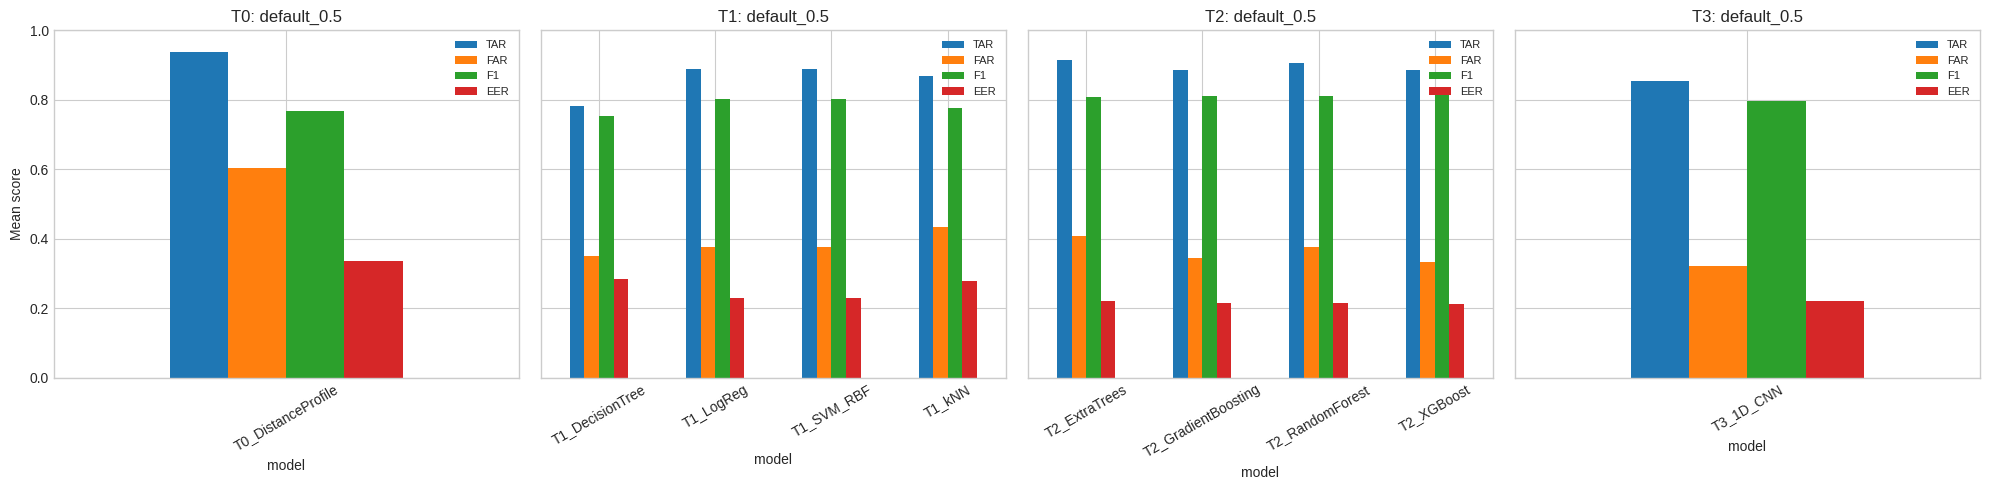

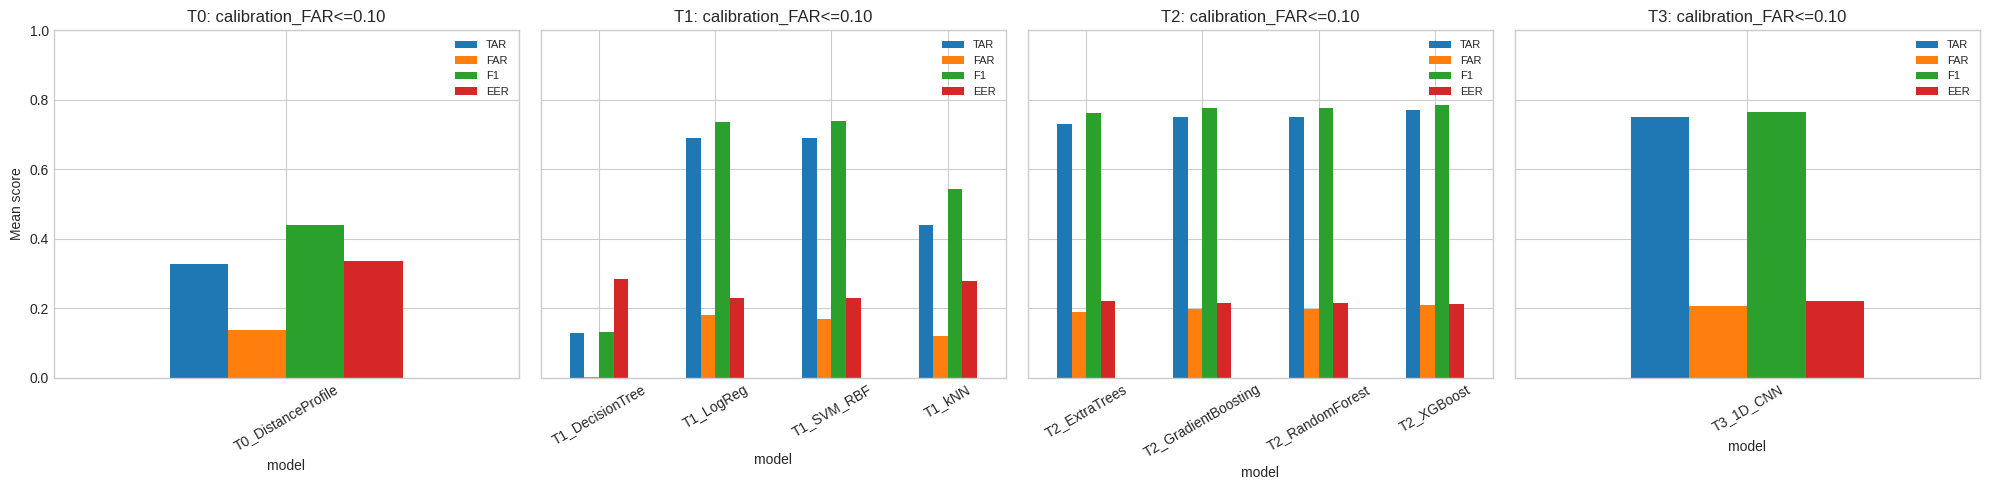

In [ ]:
# plot_metric_by_tier(): bar chart comparing tiers on a chosen metric, for a given threshold policy.
plt.style.use("seaborn-v0_8-whitegrid")

def plot_metric_by_tier(policy="default_0.5"):
    plot_df = (
        fair_results[fair_results["threshold_policy"] == policy]
        .groupby(["tier", "model"])[["TAR", "FAR", "F1", "EER"]]
        .mean()
        .reset_index()
    )
    tiers = [t for t in ["T0", "T1", "T2", "T3"] if t in set(plot_df["tier"])]
    fig, axes = plt.subplots(1, len(tiers), figsize=(5 * len(tiers), 5), sharey=True)
    if len(tiers) == 1:
        axes = [axes]
    for ax, tier_name in zip(axes, tiers):
        tier_plot = plot_df[plot_df["tier"] == tier_name].set_index("model")
        tier_plot[["TAR", "FAR", "F1", "EER"]].plot(kind="bar", ax=ax, rot=30)
        ax.set_title(f"{tier_name}: {policy}")
        ax.set_ylim(0, 1)
        ax.set_ylabel("Mean score")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_metric_by_tier("default_0.5")
plot_metric_by_tier(f"calibration_FAR<={LOW_FAR_TARGET:.2f}")


vulnerability_label
medium    35
low       33
high      32
Name: count, dtype: int64


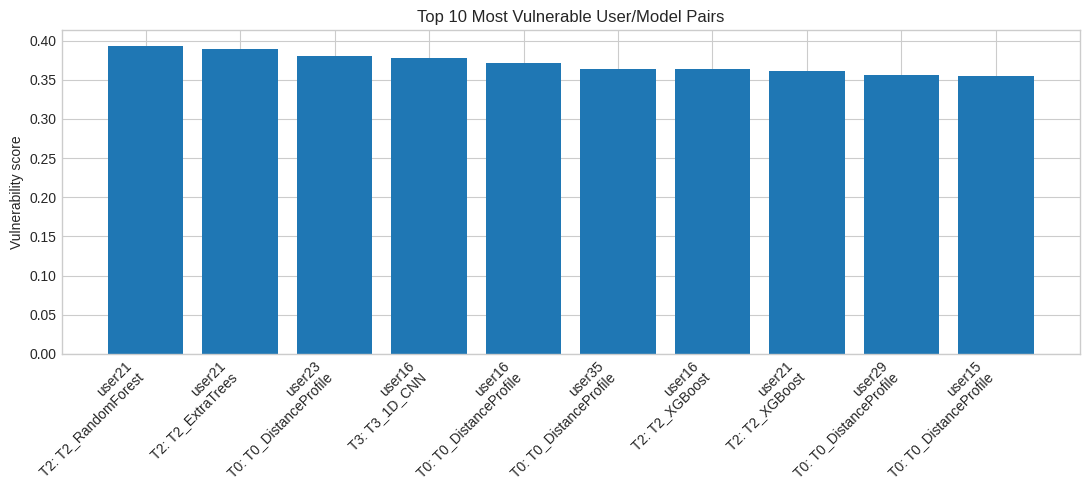

,user,tier,model,FAR,FRR,AUC,EER,vulnerability_score,vulnerability_label
47,user21,T2,T2_RandomForest,0.424603,0.321070,0.690543,0.365371,0.393543,high
45,user21,T2,T2_ExtraTrees,0.398810,0.367893,0.662134,0.381669,0.389535,high
50,user23,T0,T0_DistanceProfile,0.209021,0.780117,0.517036,0.486984,0.380350,high
29,user16,T3,T3_1D_CNN,0.330927,0.488497,0.614742,0.412972,0.378198,high
20,user16,T0,T0_DistanceProfile,0.214200,0.738898,0.502765,0.497024,0.371609,high
70,user35,T0,T0_DistanceProfile,0.193141,0.763838,0.572280,0.451339,0.364350,high
28,user16,T2,T2_XGBoost,0.374248,0.340824,0.701138,0.356804,0.364221,high
48,user21,T2,T2_XGBoost,0.384921,0.307692,0.725925,0.347836,0.361752,high
60,user29,T0,T0_DistanceProfile,0.203704,0.713467,0.659164,0.386451,0.356633,high
10,user15,T0,T0_DistanceProfile,0.240919,0.620482,0.655265,0.388956,0.354788,high


In [ ]:
vulnerability_policy = f"calibration_FAR<={LOW_FAR_TARGET:.2f}"
vulnerability = (
    fair_results[fair_results["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["TAR", "FAR", "FRR", "F1", "AUC", "EER"]]
    .mean()
    .reset_index()
)
vulnerability["vulnerability_score"] = 0.7 * vulnerability["FAR"] + 0.3 * vulnerability["FRR"]

# Low/medium/high labels via tertiles of the observed score distribution.
# Quantile-based (rather than fixed cutoffs like 0.25/0.50) keeps the three
# classes roughly balanced regardless of how spread out the scores are,
# which matters with a small number of user/tier/model rows.
vulnerability["vulnerability_label"] = pd.qcut(
    vulnerability["vulnerability_score"], q=3, labels=["low", "medium", "high"]
)
print(vulnerability["vulnerability_label"].value_counts())

top_vulnerable = vulnerability.sort_values("vulnerability_score", ascending=False).head(10).copy()
top_vulnerable["label"] = top_vulnerable["user"] + "\n" + top_vulnerable["tier"] + ": " + top_vulnerable["model"]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(top_vulnerable["label"], top_vulnerable["vulnerability_score"])
ax.set_title("Top 10 Most Vulnerable User/Model Pairs")
ax.set_ylabel("Vulnerability score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_vulnerable[["user", "tier", "model", "FAR", "FRR", "AUC", "EER", "vulnerability_score", "vulnerability_label"]]


In [ ]:
# Builds `vulnerability_features`: clean-side vulnerability scores merged with
# each user/tier/model's calibrated decision_threshold. Reused below by the
# real Vulnerability Classifier v2 (which merges in actual SapiAgent bypass rate).
vuln_lookup = (
    fair_results[fair_results["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["decision_threshold"]]
    .mean()
    .reset_index()
)
vulnerability_features = vulnerability.merge(vuln_lookup, on=["user", "tier", "model"], how="left")
vulnerability_features.head()


,user,tier,model,TAR,FAR,FRR,F1,AUC,EER,vulnerability_score,vulnerability_label,decision_threshold
0,user12,T0,T0_DistanceProfile,0.298032,0.126621,0.701968,0.427416,0.692866,0.370829,0.299225,medium,0.689868
1,user12,T1,T1_DecisionTree,0.000000,0.000000,1.000000,0.000000,0.705415,0.294585,0.300000,medium,1.000000
2,user12,T1,T1_LogReg,0.682292,0.142639,0.317708,0.761991,0.873075,0.210587,0.195160,low,0.717868
3,user12,T1,T1_SVM_RBF,0.684606,0.145690,0.315394,0.762653,0.868667,0.215480,0.196601,low,0.730899
4,user12,T1,T1_kNN,0.365741,0.090770,0.634259,0.508897,0.771954,0.295103,0.253817,medium,1.000000


/tmp/ipykernel_3469/353719507.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, show=True)


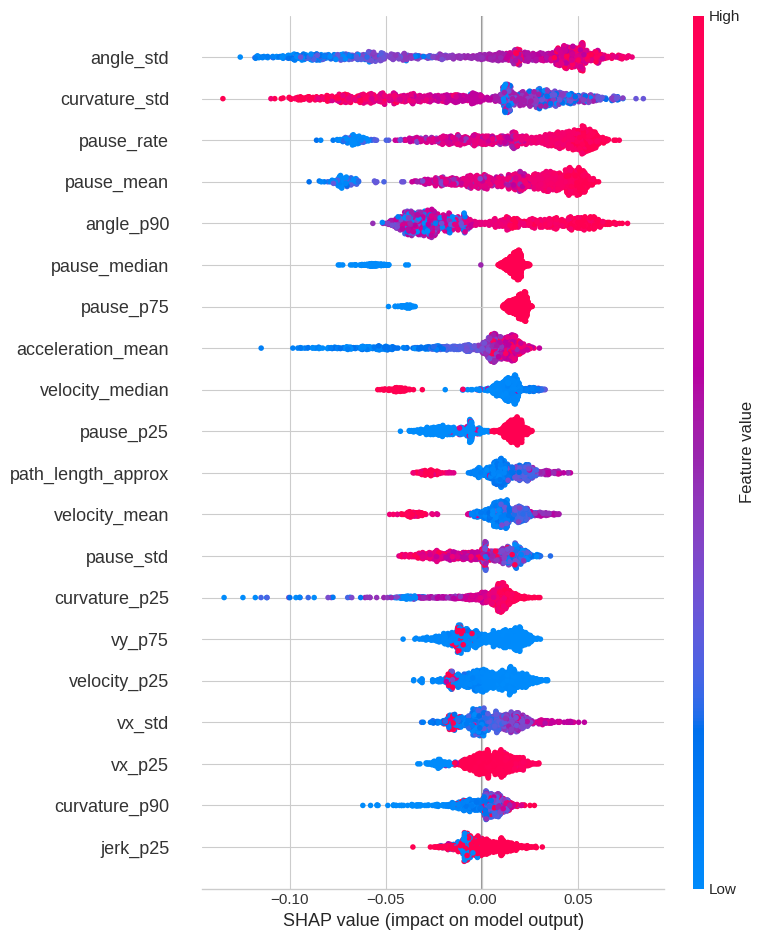

In [ ]:
## SHAP Feature Importance (T2 Tree Models)

# !pip install shap --quiet   # uncomment if not already installed in your Colab session

import shap

def run_user_shap(user, seed=0, model_name="T2_RandomForest"):
    splits = get_fair_user_splits(user, seed=seed)
    models = build_t2_models(seed)
    model = models[model_name]
    model.fit(splits["X_fit_tab"], splits["y_fit"])

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(splits["X_test_tab"])

    # Handle both SHAP output formats:
    # - old: list of arrays, one per class -> take class 1 ("genuine")
    # - new: single 3D array (samples, features, classes) -> slice class 1
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    return shap_values, splits["X_test_tab"]

shap_values, X_shap = run_user_shap(example_user, seed=0, model_name="T2_RandomForest")
shap.summary_plot(shap_values, X_shap, show=True)

In [ ]:
## Multi-User SHAP Consistency Check

def get_user_shap_importance(user, seed=0, model_name="T2_RandomForest"):
    shap_values, X_shap = run_user_shap(user, seed=seed, model_name=model_name)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    return pd.Series(mean_abs_shap, index=X_shap.columns)

# Start with a handful of users rather than all 10 - SHAP + retraining per user adds up.
# Widen check_users to sorted(user_counts.keys()) later if this looks useful.
check_users = sorted(user_counts.keys())[:5]

importance_by_user = {}
for u in check_users:
    print(f"Computing SHAP importance for {u}...")
    importance_by_user[u] = get_user_shap_importance(u, seed=0)

importance_df = pd.DataFrame(importance_by_user)  # rows = features, columns = users
importance_df["mean_importance"] = importance_df.mean(axis=1)

# rank_std: how much a feature's rank position jumps around between users.
# Low rank_std + high mean_importance = a feature that's reliably important
# everywhere, not just for one user.
ranks = importance_df[check_users].rank(ascending=False)
importance_df["rank_std"] = ranks.std(axis=1)

top_features = importance_df.sort_values("mean_importance", ascending=False).head(15)
top_features[["mean_importance", "rank_std"] + check_users]

Computing SHAP importance for user12...
Computing SHAP importance for user15...
Computing SHAP importance for user16...
Computing SHAP importance for user20...
Computing SHAP importance for user21...


,mean_importance,rank_std,user12,user15,user16,user20,user21
pause_mean,0.028637,4.505552,0.032824,0.014494,0.033478,0.039202,0.023185
pause_rate,0.026286,5.787918,0.035460,0.011901,0.027155,0.036515,0.020398
curvature_p25,0.025109,9.984989,0.014022,0.040510,0.015768,0.006007,0.049239
curvature_std,0.022426,9.591663,0.037626,0.007276,0.020320,0.026487,0.020424
acceleration_std,0.020255,8.080842,0.007498,0.023847,0.026245,0.014168,0.029518
curvature_p75,0.017629,16.769019,0.004130,0.043589,0.004453,0.005076,0.030895
pause_median,0.017214,11.388591,0.021465,0.004671,0.016048,0.024211,0.019674
angle_std,0.016359,14.515509,0.047042,0.013197,0.004211,0.004548,0.012798
curvature_p90,0.015041,15.738488,0.008519,0.041832,0.004627,0.002908,0.017321
angle_p90,0.014853,11.882761,0.031020,0.019756,0.005004,0.012291,0.006194


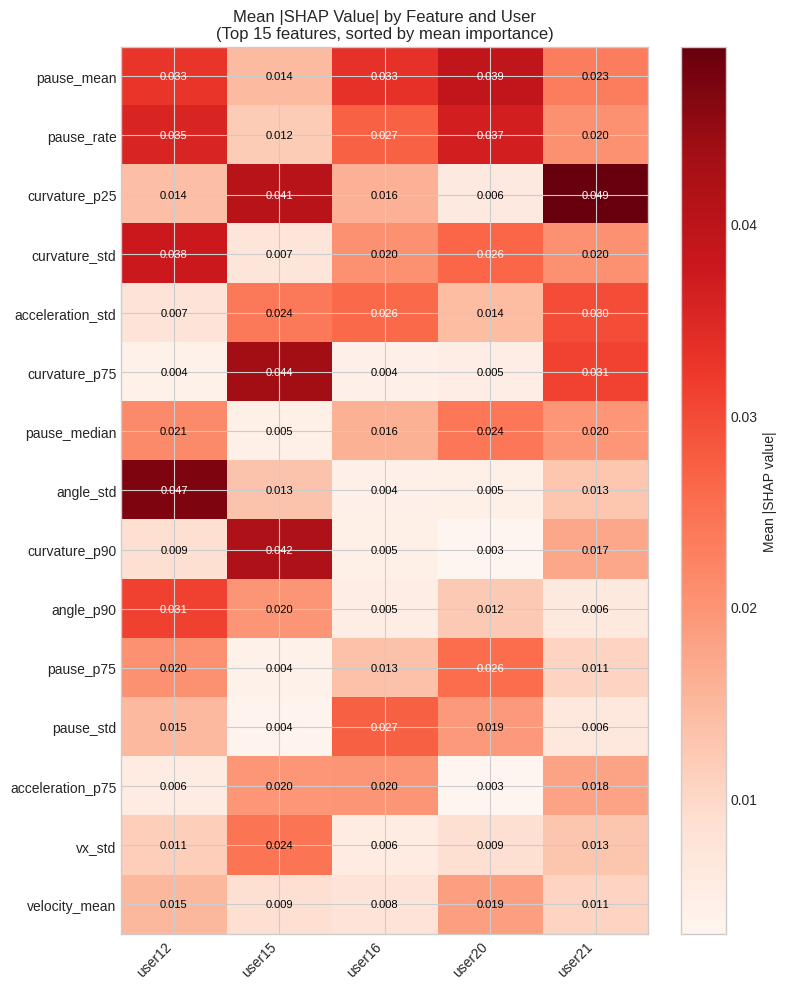

In [ ]:
## SHAP Importance Heatmap Across Users

heatmap_data = top_features[check_users]  # reuse the same top 15 features/users from before

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="Reds")

ax.set_xticks(range(len(check_users)))
ax.set_xticklabels(check_users, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index)

# Annotate each cell with its value for readability.
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                color="white" if val > heatmap_data.values.max() * 0.5 else "black",
                fontsize=8)

ax.set_title("Mean |SHAP Value| by Feature and User\n(Top 15 features, sorted by mean importance)")
fig.colorbar(im, ax=ax, label="Mean |SHAP value|")
plt.tight_layout()
plt.show()

# Attacker Scoring Infrastructure

Shared functions used by both WindMouse and SapiAgent below: fits each tier's models per user/seed, calibrates thresholds (including the floor variant), and scores attack sessions against them.

In [ ]:
# ================= ALL-TIERS ATTACK BYPASS SCORING (A1 vs A2) =================
# Needs in scope: all_sessions, test_sessions,
# user_counts, get_fair_user_splits, windows_from_sessions, windows_to_tabular,
# threshold_for_target_far, predict_genuine_scores, t0_distance_profile_scores,
# build_t1_models, build_t2_models, build_cnn_fair, and the constants
# (WINDOW, LOW_FAR_TARGET, vulnerability_policy, T3_EPOCHS, T3_VALIDATION_SIZE,
# T3_BATCH_SIZE).
import glob, os
import numpy as np, pandas as pd

ENROLLED_USERS = sorted(user_counts.keys())
ATTACK_SEEDS   = [0, 1, 2]

def load_attack_sessions_by_seed(root, seeds=ATTACK_SEEDS):
    # bare read_csv (already portability-verified); extract_features only needs
    # record timestamp / x / y, which the handoff CSVs have.
    out = {}
    for s in seeds:
        paths = sorted(glob.glob(os.path.join(root, f"seed{s}", "*.csv")))
        out[s] = [pd.read_csv(p) for p in paths]
    return out

def _session_bypassed(win_scores, thr):
    # SESSION RULE (keep identical for BOTH attackers): majority of windows accepted.
    # To use a mean-evidence rule instead, swap for: return win_scores.mean() >= thr
    return float(np.mean(win_scores >= thr)) >= 0.5

def _attack_bypass(score_windows, thr, sessions):
    pooled, sess_flags = [], []
    for sess in sessions:
        Xw, _ = windows_from_sessions([sess], 1)   # per-session windows; label unused
        if len(Xw) == 0:
            continue
        sc = np.asarray(score_windows(Xw), dtype=float)
        pooled.append(sc)
        sess_flags.append(_session_bypassed(sc, thr))
    pooled = np.concatenate(pooled) if pooled else np.array([])
    win_rate  = float(np.mean(pooled >= thr)) if pooled.size else 0.0
    sess_rate = float(np.mean(sess_flags)) if sess_flags else 0.0
    return win_rate, sess_rate

def _tier_scorers(user, seed, t3_epochs):
    # Fit each tier's model(s) on this user's FIT split, calibrate on CAL under
    # BOTH the plain FAR<=0.10 policy and a floored variant (threshold can't
    # drop below THRESHOLD_FLOOR). Returns {(tier, model): (score_windows_fn, {policy_name: threshold})}.
    splits = get_fair_user_splits(user, seed=seed)
    scorers = {}

    def _thresholds(y_cal, cal_scores):
        thr, _, _ = threshold_for_target_far(y_cal, cal_scores, LOW_FAR_TARGET)
        thr_floor, _, _ = threshold_for_target_far(y_cal, cal_scores, LOW_FAR_TARGET, min_threshold=THRESHOLD_FLOOR)
        return {
            f"calibration_FAR<={LOW_FAR_TARGET:.2f}": thr,
            f"calibration_FAR<={LOW_FAR_TARGET:.2f}_floor_{THRESHOLD_FLOOR:.2f}": thr_floor,
        }

    # T0 distance profile
    def t0_score(Xw, _s=splits):
        return t0_distance_profile_scores(_s["X_fit_tab"], _s["y_fit"], windows_to_tabular(Xw))
    cal = t0_distance_profile_scores(splits["X_fit_tab"], splits["y_fit"], splits["X_cal_tab"])
    scorers[("T0", "T0_DistanceProfile")] = (t0_score, _thresholds(splits["y_cal"], cal))

    # T1 + T2 tabular sklearn
    for tier, builder in [("T1", build_t1_models), ("T2", build_t2_models)]:
        for name, model in builder(seed).items():
            model.fit(splits["X_fit_tab"], splits["y_fit"])
            cal = predict_genuine_scores(model, splits["X_cal_tab"])
            scorers[(tier, name)] = (
                (lambda Xw, m=model: predict_genuine_scores(m, windows_to_tabular(Xw))),
                _thresholds(splits["y_cal"], cal))

    # T3 1D-CNN on sequences (same train/val split + scaler as run_user_t3_fair)
    np.random.seed(seed); pyrandom.seed(seed); tf.random.set_seed(seed)
    fit_idx = np.arange(len(splits["y_fit"]))
    tr_idx, val_idx = train_test_split(fit_idx, test_size=T3_VALIDATION_SIZE,
                                       stratify=splits["y_fit"], random_state=seed)
    f = splits["X_fit_seq"].shape[2]
    scaler = StandardScaler().fit(splits["X_fit_seq"][tr_idx].reshape(-1, f))
    def _scale(seq): return scaler.transform(seq.reshape(-1, f)).reshape(seq.shape)
    cnn = build_cnn_fair(input_shape=(WINDOW, f))
    es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
    cnn.fit(_scale(splits["X_fit_seq"][tr_idx]), splits["y_fit"][tr_idx],
            validation_data=(_scale(splits["X_fit_seq"][val_idx]), splits["y_fit"][val_idx]),
            epochs=t3_epochs, batch_size=T3_BATCH_SIZE, callbacks=[es], verbose=0)
    cal = cnn.predict(_scale(splits["X_cal_seq"]), verbose=0).ravel()
    def t3_score(Xw, _c=cnn, _sc=_scale): return _c.predict(_sc(Xw), verbose=0).ravel()
    scorers[("T3", "T3_1D_CNN")] = (t3_score, _thresholds(splits["y_cal"], cal))
    return scorers

import time

def score_attack_all_tiers(attack_by_seed, attack_type, t3_epochs=T3_EPOCHS,
                           users=ENROLLED_USERS, seeds=ATTACK_SEEDS):
    # Pairs defender(seed) with that seed's attack sessions. One row per
    # (user, tier, model, threshold_policy, seed) - now scored against BOTH
    # the plain FAR<=0.10 threshold and the floored variant, for direct comparison.
    _t0 = time.time()
    rows = []
    for seed in seeds:
        sessions = attack_by_seed[seed]
        for user in users:
            print(f"[{attack_type}] seed={seed} user={user} elapsed={time.time()-_t0:.1f}s")
            for (tier, model_name), (score_fn, thr_dict) in _tier_scorers(user, seed, t3_epochs).items():
                for policy_name, thr in thr_dict.items():
                    wr, sr = _attack_bypass(score_fn, thr, sessions)
                    rows.append({"user": user, "tier": tier, "model": model_name,
                                 "threshold_policy": policy_name, "attack_type": attack_type,
                                 "seed": seed, "accept_threshold": thr,
                                 "bypass_rate_window": wr, "bypass_rate_session": sr})
        print(f"[{attack_type}] seed {seed} done - elapsed={time.time()-_t0:.1f}s")
    print(f"[{attack_type}] fully done in {time.time()-_t0:.1f}s")
    return pd.DataFrame(rows)

# Attacker Results: WindMouse

Two versions below: the original T3-only result (from the partner's earlier run, hardcoded), and a new all-tiers run scored using the same infrastructure as SapiAgent, so the two attackers can be compared directly across every tier.

In [ ]:
## Robustness Drop (Clean FAR vs. Attack Bypass Rate)

# REAL attack_results from the partner's WindMouse (T6) run.
# Source: Week5REU_BehavioralAuth_final_fair_T0_T1_T2_T3.ipynb,
#   run_windmouse_t6(n_attack_sessions=20, seeds=[0,1,2]), policy
#   calibration_FAR<=0.10, bypass rates averaged over the 3 seeds.
# WindMouse was scored against the T3 1D-CNN (the deployed sequence defender),
# so every row is tier="T3", model="T3_1D_CNN" to match fair_results and let
# the clean-FAR merge below resolve. NOTE: only T3 was tested for WindMouse -
# unlike SapiAgent (all four tiers) below. Ask partner for all-tier WindMouse
# results if a like-for-like comparison across tiers is needed.
# Uses attack_results_windmouse (not attack_results) so it does not get
# silently overwritten by the SapiAgent run later in this notebook.

ATTACK_RESULTS_READY = True

# (bypass_rate_window, bypass_rate_session) per user, seed-averaged, FAR<=0.10.
windmouse_bypass = {
    "user15": (0.798146, 0.950000),
    "user9":  (0.699536, 0.933333),
    "user23": (0.652528, 0.700000),
    "user35": (0.237637, 0.000000),
    "user12": (0.174365, 0.000000),
    "user7":  (0.094203, 0.016667),
    "user16": (0.087179, 0.000000),
    "user29": (0.082051, 0.016667),
    "user21": (0.000000, 0.000000),
    "user20": (0.000000, 0.000000),
}

attack_results_windmouse = pd.DataFrame(
    [
        {
            "user": u,
            "tier": "T3",
            "model": "T3_1D_CNN",
            "threshold_policy": vulnerability_policy,   # "calibration_FAR<=0.10"
            "attack_type": "windmouse",
            "bypass_rate_window": bw,
            "bypass_rate_session": bs,
        }
        for u, (bw, bs) in windmouse_bypass.items()
    ]
)

# Guard: every attacked user must exist in the clean T3 results, else the merge
# below silently yields NaN clean_FAR.
_clean_users = set(
    fair_results[
        (fair_results["threshold_policy"] == vulnerability_policy)
        & (fair_results["tier"] == "T3")
        & (fair_results["model"] == "T3_1D_CNN")
    ]["user"]
)
_missing = set(attack_results_windmouse["user"]) - _clean_users
assert not _missing, f"attack_results users missing from clean T3 fair_results: {_missing}"
print(f"Loaded REAL WindMouse attack_results_windmouse: {len(attack_results_windmouse)} rows, "
      f"{attack_results_windmouse['user'].nunique()} users, tier=T3/T3_1D_CNN.")

# --- Robustness drop computation (unchanged from the handoff contract) ---
clean_far = (
    fair_results[fair_results["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["FAR"]]
    .mean()
    .reset_index()
    .rename(columns={"FAR": "clean_FAR"})
)

robustness_windmouse = attack_results_windmouse.merge(clean_far, on=["user", "tier", "model"], how="left")
robustness_windmouse["robustness_drop_window"] = robustness_windmouse["bypass_rate_window"] - robustness_windmouse["clean_FAR"]
robustness_windmouse["robustness_drop_session"] = robustness_windmouse["bypass_rate_session"] - robustness_windmouse["clean_FAR"]

# Only 10 rows here (one per user, T3 only) - this is the WindMouse robustness
# table, separate from the SapiAgent one (all tiers) further down.
robustness_windmouse.sort_values("robustness_drop_window", ascending=False)[
    ["user", "tier", "model", "attack_type", "clean_FAR", "bypass_rate_window",
     "robustness_drop_window", "bypass_rate_session", "robustness_drop_session"]
].head(15)

Loaded REAL WindMouse attack_results_windmouse: 10 rows, 10 users, tier=T3/T3_1D_CNN.


,user,tier,model,attack_type,clean_FAR,bypass_rate_window,robustness_drop_window,bypass_rate_session,robustness_drop_session
1,user9,T3,T3_1D_CNN,windmouse,0.025547,0.699536,0.673989,0.933333,0.907786
0,user15,T3,T3_1D_CNN,windmouse,0.287927,0.798146,0.510219,0.950000,0.662073
2,user23,T3,T3_1D_CNN,windmouse,0.218922,0.652528,0.433606,0.700000,0.481078
5,user7,T3,T3_1D_CNN,windmouse,0.004049,0.094203,0.090154,0.016667,0.012618
4,user12,T3,T3_1D_CNN,windmouse,0.163997,0.174365,0.010368,0.000000,-0.163997
9,user20,T3,T3_1D_CNN,windmouse,0.007634,0.000000,-0.007634,0.000000,-0.007634
3,user35,T3,T3_1D_CNN,windmouse,0.382671,0.237637,-0.145034,0.000000,-0.382671
6,user16,T3,T3_1D_CNN,windmouse,0.330927,0.087179,-0.243748,0.000000,-0.330927
8,user21,T3,T3_1D_CNN,windmouse,0.257937,0.000000,-0.257937,0.000000,-0.257937
7,user29,T3,T3_1D_CNN,windmouse,0.390741,0.082051,-0.308690,0.016667,-0.374074


In [ ]:
## Dr. Duan: aggregate bypass across ALL users
# Uses attack_results_windmouse (not attack_results, which holds SapiAgent data below)
wm = attack_results_windmouse[attack_results_windmouse["attack_type"] == "windmouse"]
for col in ["bypass_rate_session", "bypass_rate_window"]:
    s = wm[col]
    print(f"{col}: mean={s.mean():.3f}  std={s.std():.3f}  median={s.median():.3f}  "
          f"min={s.min():.3f}  max={s.max():.3f}")
    print(f"  users >0.70: {(s > 0.70).sum()} / {len(s)}   at 0.00: {(s == 0).sum()} / {len(s)}")

bypass_rate_session: mean=0.262  std=0.419  median=0.008  min=0.000  max=0.950
  users >0.70: 2 / 10   at 0.00: 5 / 10
bypass_rate_window: mean=0.283  std=0.310  median=0.134  min=0.000  max=0.798
  users >0.70: 1 / 10   at 0.00: 2 / 10


## WindMouse (All Tiers) - Scored by Us

Same scoring infrastructure used for SapiAgent above, applied to the raw WindMouse session files, so both attackers are directly comparable across all four tiers rather than just T3.

In [ ]:
# Loads the raw WindMouse attack session CSVs (seed0/seed1/seed2) from Drive.
# Expect 20 sessions per seed - if any print 0, the files aren't at this path yet.
windmouse_by_seed = load_attack_sessions_by_seed("/content/drive/MyDrive/handoff/windmouse_sessions")
for s in [0, 1, 2]:
    print(f"seed {s}: {len(windmouse_by_seed[s])} sessions loaded")


seed 0: 20 sessions loaded
seed 1: 20 sessions loaded
seed 2: 20 sessions loaded


In [ ]:
# Same scoring pipeline used for SapiAgent - now gives WindMouse across all
# four tiers instead of just T3, so it is directly comparable to SapiAgent's
# results below. Retrains T1/T2/T3 per user/seed, so expect similar runtime
# to the SapiAgent full run above.
windmouse_all_tiers_rows = score_attack_all_tiers(windmouse_by_seed, "windmouse_all_tiers", t3_epochs=T3_EPOCHS)
windmouse_all_tiers_rows.to_csv("/content/drive/MyDrive/windmouse_all_tiers_with_floor.csv", index=False)
print("rows:", len(windmouse_all_tiers_rows), "| tiers:", sorted(windmouse_all_tiers_rows.tier.unique()))


[windmouse_all_tiers] seed=0 user=user12 elapsed=0.0s
[windmouse_all_tiers] seed=0 user=user15 elapsed=104.1s
[windmouse_all_tiers] seed=0 user=user16 elapsed=193.3s
[windmouse_all_tiers] seed=0 user=user20 elapsed=283.8s
[windmouse_all_tiers] seed=0 user=user21 elapsed=405.7s
[windmouse_all_tiers] seed=0 user=user23 elapsed=483.6s
[windmouse_all_tiers] seed=0 user=user29 elapsed=564.6s
[windmouse_all_tiers] seed=0 user=user35 elapsed=631.0s
[windmouse_all_tiers] seed=0 user=user7 elapsed=703.0s
[windmouse_all_tiers] seed=0 user=user9 elapsed=846.1s
[windmouse_all_tiers] seed 0 done - elapsed=1008.1s
[windmouse_all_tiers] seed=1 user=user12 elapsed=1008.1s
[windmouse_all_tiers] seed=1 user=user15 elapsed=1119.6s
[windmouse_all_tiers] seed=1 user=user16 elapsed=1212.9s
[windmouse_all_tiers] seed=1 user=user20 elapsed=1307.4s
[windmouse_all_tiers] seed=1 user=user21 elapsed=1428.6s
[windmouse_all_tiers] seed=1 user=user23 elapsed=1509.9s
[windmouse_all_tiers] seed=1 user=user29 elapsed=1

# Attacker Results: SapiAgent (All Tiers)

SapiAgent covers all four tiers (T0-T3), scored against both the plain FAR<=0.10 threshold and the floored variant (`calibration_FAR<=0.10_floor_0.05`) for direct comparison.

In [ ]:
sapi_by_seed = load_attack_sessions_by_seed("/content/drive/MyDrive/handoff/sapiagent_sessions")

In [ ]:
# Loads the raw SapiAgent attack session CSVs (seed0/seed1/seed2) from Drive.
# Expect 20 sessions per seed - if any print 0, the files aren't at this path yet.
import glob
print(len(glob.glob("/content/drive/MyDrive/handoff/sapiagent_sessions/seed0/*.csv")))  # expect 20

20


In [ ]:
# SMOKE: one user, one seed, few epochs. Expect a small table with sane 0..1 rates.
_smoke = score_attack_all_tiers({0: sapi_by_seed[0]}, "sapiagent_smoke",
                                t3_epochs=5, users=[ENROLLED_USERS[0]], seeds=[0])
display(_smoke[["tier","model","accept_threshold","bypass_rate_window","bypass_rate_session"]])

[sapiagent_smoke] seed=0 user=user12 elapsed=0.0s
[sapiagent_smoke] seed 0 done - elapsed=103.2s
[sapiagent_smoke] fully done in 103.2s


,tier,model,accept_threshold,bypass_rate_window,bypass_rate_session
0,T0,T0_DistanceProfile,0.686107,0.000000,0.0
1,T0,T0_DistanceProfile,0.686107,0.000000,0.0
2,T1,T1_LogReg,0.690790,0.070833,0.0
3,T1,T1_LogReg,0.690790,0.070833,0.0
4,T1,T1_SVM_RBF,0.745348,0.000000,0.0
5,T1,T1_SVM_RBF,0.745348,0.000000,0.0
6,T1,T1_kNN,1.000000,0.237500,0.0
7,T1,T1_kNN,1.000000,0.237500,0.0
8,T1,T1_DecisionTree,1.000000,0.000000,0.0
9,T1,T1_DecisionTree,1.000000,0.000000,0.0


In [36]:
# FULL run (T3 refits 10 users x 3 seeds = the slow part; keep T3_EPOCHS for final numbers)
# `attack_results` here = SapiAgent only, all four tiers, both threshold policies.
# WindMouse's data lives separately in `attack_results_windmouse` (T3 only) above -
# no more collision since the rename, but they are still analyzed separately, not combined.
sapi_rows = score_attack_all_tiers(sapi_by_seed, "sapiagent", t3_epochs=T3_EPOCHS)

attack_results = sapi_rows.copy()
attack_results.to_csv("/content/drive/MyDrive/attack_results_all_tiers_with_floor.csv", index=False)  # new filename - does not overwrite the original
print("rows:", len(attack_results), "| tiers:", sorted(attack_results.tier.unique()))

[sapiagent] seed=0 user=user12 elapsed=0.0s
[sapiagent] seed=0 user=user15 elapsed=129.2s
[sapiagent] seed=0 user=user16 elapsed=229.5s
[sapiagent] seed=0 user=user20 elapsed=331.9s
[sapiagent] seed=0 user=user21 elapsed=467.8s
[sapiagent] seed=0 user=user23 elapsed=554.4s
[sapiagent] seed=0 user=user29 elapsed=643.3s
[sapiagent] seed=0 user=user35 elapsed=718.5s
[sapiagent] seed=0 user=user7 elapsed=801.0s
[sapiagent] seed=0 user=user9 elapsed=945.0s
[sapiagent] seed 0 done - elapsed=1115.7s
[sapiagent] seed=1 user=user12 elapsed=1115.7s
[sapiagent] seed=1 user=user15 elapsed=1234.4s
[sapiagent] seed=1 user=user16 elapsed=1331.3s
[sapiagent] seed=1 user=user20 elapsed=1433.1s
[sapiagent] seed=1 user=user21 elapsed=1560.5s
[sapiagent] seed=1 user=user23 elapsed=1656.0s
[sapiagent] seed=1 user=user29 elapsed=1744.8s
[sapiagent] seed=1 user=user35 elapsed=1821.7s
[sapiagent] seed=1 user=user7 elapsed=1905.3s
[sapiagent] seed=1 user=user9 elapsed=2062.0s
[sapiagent] seed 1 done - elapsed=

In [37]:
# The real, full attack-scoring run: retrains T1/T2/T3 per user/seed and scores SapiAgent
# against both threshold policies. This is the slow step (~similar to the fair_results run).
# Output: `attack_results`, ~600 rows (10 users x 10 models x 2 policies x 3 seeds).
sa = attack_results[attack_results.attack_type == "sapiagent"]

# Dr. Duan: aggregate per defender, seed-averaged per user, report spread + bimodal shape
per_user = sa.groupby(["tier","model","user"])["bypass_rate_session"].mean().reset_index()
agg = per_user.groupby(["tier","model"])["bypass_rate_session"].agg(
    mean="mean", std="std", median="median",
    n_over_0p70=lambda x: int((x > 0.70).sum()), n_at_0=lambda x: int((x == 0).sum()))
display(agg.round(3))   # T3_1D_CNN row is the direct comparison to WindMouse's 0.262

# Paradox for A2: AUC should NOT predict bypass (~0); decision threshold should (negative)
far = fair_results[fair_results.threshold_policy == vulnerability_policy]
merged = sa.merge(far[["user","tier","model","seed","AUC","decision_threshold"]],
                  on=["user","tier","model","seed"], how="left")
for x in ["AUC", "decision_threshold"]:
    for y in ["bypass_rate_session", "bypass_rate_window"]:
        print(f"corr({x}, {y}) = {merged[[x,y]].dropna().corr().iloc[0,1]:+.3f}")

mean    std  median  n_over_0p70  n_at_0
tier model                                                         
T0   T0_DistanceProfile   0.000  0.000     0.0            0      10
T1   T1_DecisionTree      0.012  0.037     0.0            0       9
     T1_LogReg            0.202  0.417     0.0            2       7
     T1_SVM_RBF           0.100  0.316     0.0            1       9
     T1_kNN               0.018  0.035     0.0            0       7
T2   T2_ExtraTrees        0.015  0.034     0.0            0       8
     T2_GradientBoosting  0.038  0.050     0.0            0       6
     T2_RandomForest      0.005  0.011     0.0            0       8
     T2_XGBoost           0.097  0.173     0.0            0       7
T3   T3_1D_CNN            0.231  0.281     0.1            0       5

corr(AUC, bypass_rate_session) = +0.015
corr(AUC, bypass_rate_window) = +0.005
corr(decision_threshold, bypass_rate_session) = -0.174
corr(decision_threshold, bypass_rate_window) = -0.158


In [38]:
# Aggregates SapiAgent bypass rate per tier/model across users - reports mean/std/median
# and how many user/model pairs exceed 0.70 bypass vs. exactly 0 (bimodal shape check).
# Also checks correlation of AUC/decision_threshold with bypass rate.
sa = attack_results[attack_results.attack_type == "sapiagent"]
t3 = (sa[sa.model == "T3_1D_CNN"]
      .groupby("user")["bypass_rate_session"].mean()
      .sort_values(ascending=False))
print(t3.round(3))

user
user21    0.683
user12    0.650
user35    0.467
user9     0.308
user16    0.200
user15    0.000
user23    0.000
user20    0.000
user29    0.000
user7     0.000
Name: bypass_rate_session, dtype: float64


In [39]:
# T3-specific bypass rates per user, sorted descending - quick look at which users are
# most vulnerable specifically on the CNN tier.
agg.to_csv("/content/drive/MyDrive/sapiagent_bypass_by_tier_with_floor.csv")  # new filename - does not overwrite the original

In [40]:
# Saves the per-tier SapiAgent aggregate table to Drive (does not overwrite the original filename).
attack_results.groupby("threshold_policy")[["bypass_rate_window", "bypass_rate_session"]].mean()

,bypass_rate_window,bypass_rate_session
threshold_policy,,
calibration_FAR<=0.10,0.100889,0.074833
calibration_FAR<=0.10_floor_0.05,0.095167,0.068500


In [41]:
# Main comparison: mean bypass rate with vs. without the threshold floor, across all rows.
pivot = (
    attack_results[attack_results["user"].isin(["user9", "user20", "user7", "user16", "user21", "user29"])]
    .groupby(["user", "tier", "model", "threshold_policy"])[["accept_threshold", "bypass_rate_session"]]
    .mean()
    .unstack("threshold_policy")
)
pivot

accept_threshold  \
threshold_policy                calibration_FAR<=0.10   
user   tier model                                       
user16 T0   T0_DistanceProfile               0.705323   
       T1   T1_DecisionTree                  1.000000   
            T1_LogReg                        0.739524   
            T1_SVM_RBF                       0.766657   
            T1_kNN                           1.000000   
       T2   T2_ExtraTrees                    0.720000   
            T2_GradientBoosting              0.739077   
            T2_RandomForest                  0.696667   
            T2_XGBoost                       0.747166   
       T3   T3_1D_CNN                        0.515220   
user20 T0   T0_DistanceProfile               0.667509   
       T1   T1_DecisionTree                  1.000000   
            T1_LogReg                        0.685947   
            T1_SVM_RBF                       0.721699   
            T1_kNN                           1.000000   
       T2   T2_ExtraTrees                    0.630000   
            T2_GradientBoosting              0.654885   
            T2_RandomForest                  0.618889   
            T2_XGBoost                       0.644967   
       T3   T3_1D_CNN                        0.667282   
user21 T0   T0_DistanceProfile               0.708296   
       T1   T1_DecisionTree                  1.000000   
            T1_LogReg                        0.714662   
            T1_SVM_RBF                       0.744963   
            T1_kNN                           1.000000   
       T2   T2_ExtraTrees                    0.691111   
            T2_GradientBoosting              0.744373   
            T2_RandomForest                  0.650000   
            T2_XGBoost                       0.741599   
       T3   T3_1D_CNN                        0.692133   
user29 T0   T0_DistanceProfile               0.675261   
       T1   T1_DecisionTree                  1.000000   
            T1_LogReg                        0.618561   
            T1_SVM_RBF                       0.721260   
            T1_kNN                           0.866667   
       T2   T2_ExtraTrees                    0.611111   
            T2_GradientBoosting              0.546133   
            T2_RandomForest                  0.582222   
            T2_XGBoost                       0.552810   
       T3   T3_1D_CNN                        0.510580   
user7  T0   T0_DistanceProfile               0.627453   
       T1   T1_DecisionTree                  1.000000   
            T1_LogReg                        0.568349   
            T1_SVM_RBF                       0.491254   
            T1_kNN                           1.000000   
       T2   T2_ExtraTrees                    0.574444   
            T2_GradientBoosting              0.591074   
            T2_RandomForest                  0.545556   
            T2_XGBoost                       0.490880   
       T3   T3_1D_CNN                        0.363431   
user9  T0   T0_DistanceProfile               0.654860   
       T1   T1_DecisionTree                  1.000000   
            T1_LogReg                        0.122918   
            T1_SVM_RBF                       0.060398   
            T1_kNN                           0.600000   
       T2   T2_ExtraTrees                    0.157778   
            T2_GradientBoosting              0.054288   
            T2_RandomForest                  0.146667   
            T2_XGBoost                       0.017458   
       T3   T3_1D_CNN                        0.000228   

                                                                  \
threshold_policy                calibration_FAR<=0.10_floor_0.05   
user   tier model                                                  
user16 T0   T0_DistanceProfile                          0.705323   
       T1   T1_DecisionTree                             1.000000   
            T1_LogReg                                   0.739524   
            T1_SVM_RBF               

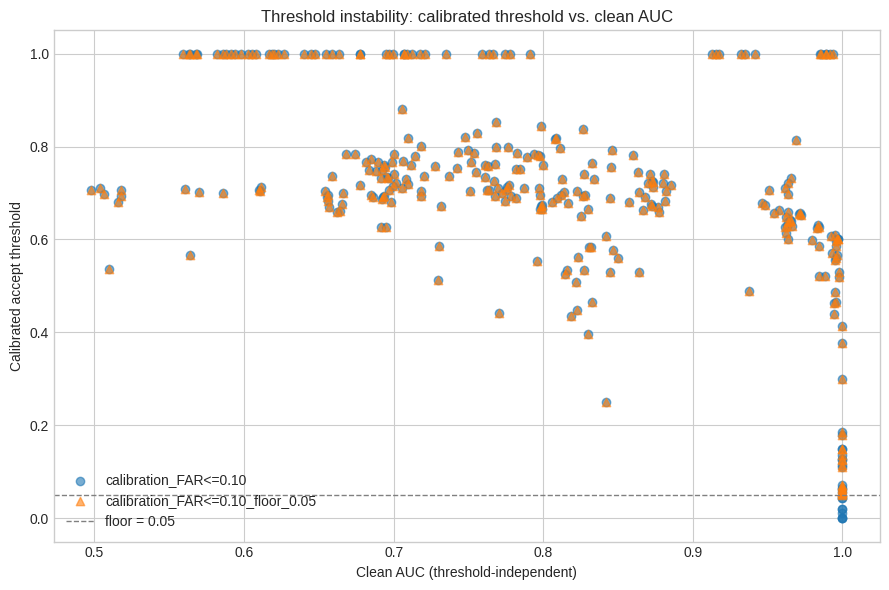

In [42]:
## Threshold Instability: Calibrated Threshold vs. Clean AUC (floor vs. no floor)

import matplotlib.pyplot as plt

# AUC is threshold-independent, so any policy row gives the same AUC per user/tier/model/seed
clean_auc = (
    fair_results[fair_results["threshold_policy"] == "default_0.5"]
    [["user", "tier", "model", "seed", "AUC"]]
)

plot_df = attack_results.merge(clean_auc, on=["user", "tier", "model", "seed"], how="left")

fig, ax = plt.subplots(figsize=(9, 6))
for policy, marker in [
    ("calibration_FAR<=0.10", "o"),
    (f"calibration_FAR<=0.10_floor_{THRESHOLD_FLOOR:.2f}", "^"),
]:
    sub = plot_df[plot_df["threshold_policy"] == policy]
    ax.scatter(sub["AUC"], sub["accept_threshold"], label=policy, alpha=0.6, marker=marker)

ax.axhline(THRESHOLD_FLOOR, linestyle="--", linewidth=1, color="gray", label=f"floor = {THRESHOLD_FLOOR}")
ax.set_xlabel("Clean AUC (threshold-independent)")
ax.set_ylabel("Calibrated accept threshold")
ax.set_title("Threshold instability: calibrated threshold vs. clean AUC")
ax.legend()
plt.tight_layout()
plt.show()

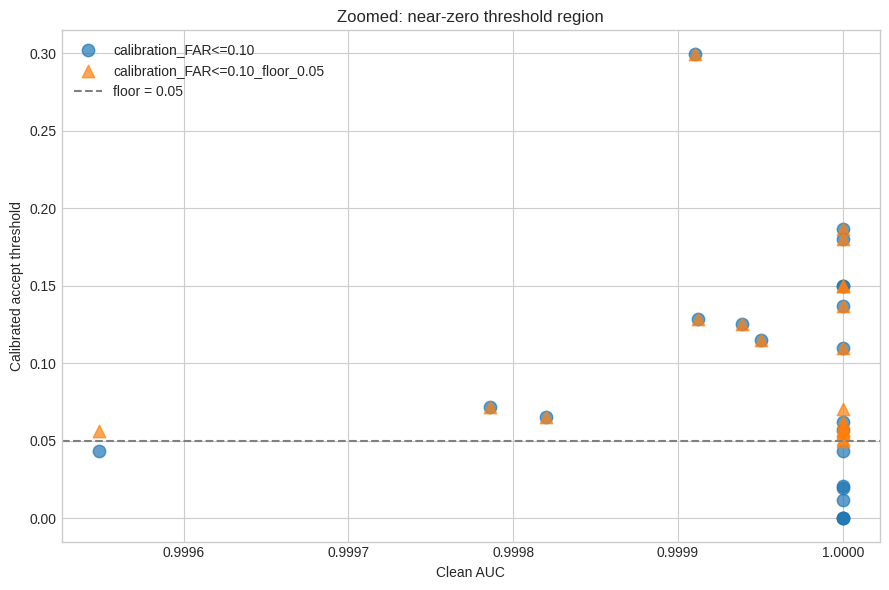

In [43]:
fig, ax = plt.subplots(figsize=(9, 6))
zoom = plot_df[(plot_df["AUC"] > 0.9) & (plot_df["accept_threshold"] < 0.35)]
for policy, marker in [
    ("calibration_FAR<=0.10", "o"),
    (f"calibration_FAR<=0.10_floor_{THRESHOLD_FLOOR:.2f}", "^"),
]:
    sub = zoom[zoom["threshold_policy"] == policy]
    ax.scatter(sub["AUC"], sub["accept_threshold"], label=policy, alpha=0.7, marker=marker, s=80)
ax.axhline(THRESHOLD_FLOOR, linestyle="--", color="gray", label=f"floor = {THRESHOLD_FLOOR}")
ax.set_xlabel("Clean AUC")
ax.set_ylabel("Calibrated accept threshold")
ax.set_title("Zoomed: near-zero threshold region")
ax.legend()
plt.tight_layout()
plt.show()

In [44]:
plot_df[(plot_df["accept_threshold"] < 0.01) & (plot_df["threshold_policy"] == "calibration_FAR<=0.10")][["user", "tier", "model", "seed", "AUC", "accept_threshold"]]

,user,tier,model,seed,AUC,accept_threshold
198,user9,T3,T3_1D_CNN,0,1.0,0.000070
398,user9,T3,T3_1D_CNN,1,1.0,0.000091
598,user9,T3,T3_1D_CNN,2,1.0,0.000522


# Vulnerability Classifier v2 (Real Bypass Data)

Upgrades the clean-only classifier above with real SapiAgent bypass rate. Binary framing (bypassed at all vs. never) - a 3-class version was tried first but collapsed entirely into one class given how few users show any bypass at all; see writeup/RQ2 for the honest result.

In [45]:
## Vulnerability Classifier v2 (real bypass rate as target)

# Average SapiAgent bypass across seeds, matching your existing vulnerability_policy
attack_bypass_avg = (
    attack_results[attack_results["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["bypass_rate_window", "bypass_rate_session"]]
    .mean()
    .reset_index()
)

vuln_v2 = vulnerability_features.merge(attack_bypass_avg, on=["user", "tier", "model"], how="inner")
print(f"Matched {len(vuln_v2)} of {len(vulnerability_features)} clean-side rows to real bypass data")
vuln_v2.head()

Matched 100 of 100 clean-side rows to real bypass data


,user,tier,model,TAR,FAR,FRR,F1,AUC,EER,vulnerability_score,vulnerability_label,decision_threshold,bypass_rate_window,bypass_rate_session
0,user12,T0,T0_DistanceProfile,0.298032,0.126621,0.701968,0.427416,0.692866,0.370829,0.299225,medium,0.689868,0.0000,0.000000
1,user12,T1,T1_DecisionTree,0.000000,0.000000,1.000000,0.000000,0.705415,0.294585,0.300000,medium,1.000000,0.0000,0.000000
2,user12,T1,T1_LogReg,0.682292,0.142639,0.317708,0.761991,0.873075,0.210587,0.195160,low,0.717868,0.1125,0.000000
3,user12,T1,T1_SVM_RBF,0.684606,0.145690,0.315394,0.762653,0.868667,0.215480,0.196601,low,0.730899,0.0000,0.000000
4,user12,T1,T1_kNN,0.365741,0.090770,0.634259,0.508897,0.771954,0.295103,0.253817,medium,1.000000,0.2750,0.083333


In [46]:
## Vulnerability Classifier v2b (binary: bypassed at all vs. never)

# With only 10 users, three classes leaves too few high/medium examples to
# learn from. Collapsing to binary (bypassed at all vs. never) uses the
# natural zero-inflated structure directly and gives the model a real signal.
vuln_v2["bypassed_label"] = (vuln_v2["bypass_rate_session"] > 0).map({True: "bypassed", False: "never_bypassed"})
print(vuln_v2["bypassed_label"].value_counts())

vuln_v2_feature_cols = ["AUC", "FAR", "FRR", "decision_threshold"]
X_vuln2b = vuln_v2[vuln_v2_feature_cols].fillna(0)
y_vuln2b = vuln_v2["bypassed_label"]

bypassed_label
never_bypassed    76
bypassed          24
Name: count, dtype: int64


In [47]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

vuln_model_v2b = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
)

cv_scores = cross_val_score(vuln_model_v2b, X_vuln2b, y_vuln2b, cv=3, scoring="accuracy")
print("CV accuracy:", cv_scores, "mean=", cv_scores.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X_vuln2b, y_vuln2b, test_size=0.30, stratify=y_vuln2b, random_state=42
)
vuln_model_v2b.fit(X_train, y_train)
pred = vuln_model_v2b.predict(X_test)

print(classification_report(y_test, pred, zero_division=0))
cm = confusion_matrix(y_test, pred, labels=vuln_model_v2b.classes_)
cm_df = pd.DataFrame(cm, index=vuln_model_v2b.classes_, columns=vuln_model_v2b.classes_)
display(cm_df)

CV accuracy: [0.82352941 0.72727273 0.63636364] mean= 0.7290552584670231
                precision    recall  f1-score   support

      bypassed       0.50      0.57      0.53         7
never_bypassed       0.86      0.83      0.84        23

      accuracy                           0.77        30
     macro avg       0.68      0.70      0.69        30
  weighted avg       0.78      0.77      0.77        30



,bypassed,never_bypassed
bypassed,4,3
never_bypassed,4,19


In [48]:
rf_v2b = vuln_model_v2b.named_steps["randomforestclassifier"]
importance_v2b = pd.DataFrame({
    "feature": vuln_v2_feature_cols,
    "importance": rf_v2b.feature_importances_
}).sort_values("importance", ascending=False)
importance_v2b

,feature,importance
1,FAR,0.339636
0,AUC,0.248221
2,FRR,0.232165
3,decision_threshold,0.179978


# Anomaly Detection v2 (Real Attacks)

Tests the post-authentication anomaly layer against real SapiAgent AND WindMouse sessions (instead of just human imposters), so catch rates can be compared between the two attackers.

In [52]:
## Anomaly Detection on Real SapiAgent Attacks

import glob

def load_attack_sessions_by_seed(root, seeds=(0, 1, 2)):
    out = {}
    for s in seeds:
        paths = sorted(glob.glob(f"{root}/seed{s}/*.csv"))
        out[s] = [pd.read_csv(p) for p in paths]
    return out

sapi_sessions_by_seed = load_attack_sessions_by_seed("/content/drive/MyDrive/handoff/sapiagent_sessions")
for s in [0, 1, 2]:
    print(f"seed {s}: {len(sapi_sessions_by_seed[s])} sessions loaded")

seed 0: 20 sessions loaded
seed 1: 20 sessions loaded
seed 2: 20 sessions loaded


In [55]:
from sklearn.ensemble import IsolationForest

ANOMALY_CONTAMINATION = 0.10  # assumed fraction of "abnormal" sessions; retune once more attack data is available

def run_user_anomaly_layer_v2(user, seed, attack_sessions=None, attack_label="sapiagent", contamination=ANOMALY_CONTAMINATION):
    splits = get_fair_user_splits(user, seed=seed)

    genuine_fit = splits["X_fit_tab"][splits["y_fit"] == 1]
    anomaly_model = make_pipeline(
        StandardScaler(),
        IsolationForest(contamination=contamination, random_state=seed)
    )
    anomaly_model.fit(genuine_fit)

    gatekeeper = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1)
    gatekeeper.fit(splits["X_fit_tab"], splits["y_fit"])
    cal_scores = predict_genuine_scores(gatekeeper, splits["X_cal_tab"])
    accept_threshold, _, _ = threshold_for_target_far(splits["y_cal"], cal_scores, target_far=LOW_FAR_TARGET)

    X_test_tab = splits["X_test_tab"]
    y_test = splits["y_test"].copy()
    session_type = np.where(y_test == 1, "genuine", "human_imposter")

    # SapiAgent sessions are a shared pool per seed (not per-target-user),
    # matching how the attacker's own bypass scoring treats them.
    if attack_sessions:
        X_attack_seq, y_attack = windows_from_sessions(attack_sessions, label=0)
        if len(X_attack_seq) > 0:
            X_attack_tab = windows_to_tabular(X_attack_seq)
            X_test_tab = pd.concat([X_test_tab, X_attack_tab], ignore_index=True)
            y_test = np.concatenate([y_test, y_attack])
            session_type = np.concatenate([session_type, np.full(len(y_attack), attack_label)])

    test_scores = predict_genuine_scores(gatekeeper, X_test_tab)
    accepted_mask = test_scores >= accept_threshold
    anomaly_pred = anomaly_model.predict(X_test_tab)
    flagged_mask = accepted_mask & (anomaly_pred == -1)

    rows = []
    for stype in np.unique(session_type):
        type_mask = session_type == stype
        n_total = int(type_mask.sum())
        n_accepted = int((type_mask & accepted_mask).sum())
        n_flagged = int((type_mask & flagged_mask).sum())
        rows.append({
            "user": user, "seed": seed, "session_type": stype,
            "n_total": n_total, "n_accepted": n_accepted,
            "accept_rate": n_accepted / n_total if n_total else np.nan,
            "n_flagged_of_accepted": n_flagged,
            "flagged_rate_of_accepted": n_flagged / n_accepted if n_accepted else np.nan,
        })
    return pd.DataFrame(rows)

anomaly_v2_rows = [
    run_user_anomaly_layer_v2(user, seed=0, attack_sessions=sapi_sessions_by_seed[0], attack_label="sapiagent")
    for user in sorted(user_counts.keys())
]
anomaly_v2_results = pd.concat(anomaly_v2_rows, ignore_index=True)
anomaly_v2_results

,user,seed,session_type,n_total,n_accepted,accept_rate,n_flagged_of_accepted,flagged_rate_of_accepted
0,user12,0,genuine,576,427,0.741319,27,0.063232
1,user12,0,human_imposter,437,79,0.180778,14,0.177215
2,user12,0,sapiagent,240,0,0.000000,0,NaN
3,user15,0,genuine,332,227,0.683735,16,0.070485
4,user15,0,human_imposter,624,114,0.182692,5,0.043860
5,user15,0,sapiagent,240,0,0.000000,0,NaN
6,user16,0,genuine,623,401,0.643660,20,0.049875
7,user16,0,human_imposter,277,95,0.342960,6,0.063158
8,user16,0,sapiagent,240,3,0.012500,3,1.000000
9,user20,0,genuine,717,538,0.750349,62,0.115242


In [56]:
# Loads the raw WindMouse attack session CSVs (seed0/seed1/seed2) from Drive,
# for the anomaly layer (separate from the all-tiers scoring load earlier).
windmouse_sessions_by_seed = load_attack_sessions_by_seed("/content/drive/MyDrive/handoff/windmouse_sessions")
for s in [0, 1, 2]:
    print(f"seed {s}: {len(windmouse_sessions_by_seed[s])} sessions loaded")


seed 0: 20 sessions loaded
seed 1: 20 sessions loaded
seed 2: 20 sessions loaded


In [57]:
# Same anomaly layer, same gatekeeper logic - now tested against WindMouse
# sessions instead of SapiAgent, labeled accordingly for the comparison below.
windmouse_anomaly_rows = [
    run_user_anomaly_layer_v2(user, seed=0, attack_sessions=windmouse_sessions_by_seed[0], attack_label="windmouse")
    for user in sorted(user_counts.keys())
]
windmouse_anomaly_results = pd.concat(windmouse_anomaly_rows, ignore_index=True)
windmouse_anomaly_results


,user,seed,session_type,n_total,n_accepted,accept_rate,n_flagged_of_accepted,flagged_rate_of_accepted
0,user12,0,genuine,576,427,0.741319,27,0.063232
1,user12,0,human_imposter,437,79,0.180778,14,0.177215
2,user12,0,windmouse,121,1,0.008264,1,1.000000
3,user15,0,genuine,332,227,0.683735,16,0.070485
4,user15,0,human_imposter,624,114,0.182692,5,0.043860
5,user15,0,windmouse,121,8,0.066116,8,1.000000
6,user16,0,genuine,623,401,0.643660,20,0.049875
7,user16,0,human_imposter,277,95,0.342960,6,0.063158
8,user16,0,windmouse,121,0,0.000000,0,NaN
9,user20,0,genuine,717,538,0.750349,62,0.115242


## Anomaly Layer Comparison: SapiAgent vs. WindMouse

Direct comparison of accept rate and flagged-of-accepted rate for both attackers, same gatekeeper and anomaly model.

In [58]:
combined_anomaly = pd.concat([anomaly_v2_results, windmouse_anomaly_results], ignore_index=True)

# Focus on the attack rows only (skip genuine/human_imposter, already covered above)
attack_rows_only = combined_anomaly[combined_anomaly["session_type"].isin(["sapiagent", "windmouse"])]

anomaly_comparison = (
    attack_rows_only
    .groupby("session_type")[["accept_rate", "flagged_rate_of_accepted"]]
    .mean()
    .round(3)
)
anomaly_comparison


,accept_rate,flagged_rate_of_accepted
session_type,,
sapiagent,0.030,1.0
windmouse,0.031,1.0


# Robustness Drop (Real SapiAgent Data)

Compares clean FAR against real attack bypass rate - the direct test of whether clean performance predicts attack robustness.

In [59]:
## Robustness Drop (Clean FAR vs. Real SapiAgent Bypass Rate)

clean_far = (
    fair_results[fair_results["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["FAR"]]
    .mean()
    .reset_index()
    .rename(columns={"FAR": "clean_FAR"})
)

# Real data now, both threshold policies (with vs. without the floor)
robustness = attack_results.merge(clean_far, on=["user", "tier", "model"], how="left")
robustness["robustness_drop_window"] = robustness["bypass_rate_window"] - robustness["clean_FAR"]
robustness["robustness_drop_session"] = robustness["bypass_rate_session"] - robustness["clean_FAR"]

robustness.sort_values("robustness_drop_session", ascending=False)[
    ["user", "tier", "model", "threshold_policy", "attack_type",
     "clean_FAR", "bypass_rate_session", "robustness_drop_session"]
].head(15)

,user,tier,model,threshold_policy,attack_type,clean_FAR,bypass_rate_session,robustness_drop_session
584,user9,T1,T1_SVM_RBF,calibration_FAR<=0.10,sapiagent,0.008516,1.0,0.991484
184,user9,T1,T1_SVM_RBF,calibration_FAR<=0.10,sapiagent,0.008516,1.0,0.991484
185,user9,T1,T1_SVM_RBF,calibration_FAR<=0.10_floor_0.05,sapiagent,0.008516,1.0,0.991484
385,user9,T1,T1_SVM_RBF,calibration_FAR<=0.10_floor_0.05,sapiagent,0.008516,1.0,0.991484
384,user9,T1,T1_SVM_RBF,calibration_FAR<=0.10,sapiagent,0.008516,1.0,0.991484
585,user9,T1,T1_SVM_RBF,calibration_FAR<=0.10_floor_0.05,sapiagent,0.008516,1.0,0.991484
598,user9,T3,T3_1D_CNN,calibration_FAR<=0.10,sapiagent,0.025547,1.0,0.974453
342,user35,T1,T1_LogReg,calibration_FAR<=0.10,sapiagent,0.237665,1.0,0.762335
543,user35,T1,T1_LogReg,calibration_FAR<=0.10_floor_0.05,sapiagent,0.237665,1.0,0.762335
542,user35,T1,T1_LogReg,calibration_FAR<=0.10,sapiagent,0.237665,1.0,0.762335


# Attacker Comparison: SapiAgent vs. WindMouse (Both All Tiers)

Both attackers now scored with the same infrastructure across all four tiers and both threshold policies, so this is a direct, like-for-like comparison of which attacker is more effective.

In [60]:
# Combine both attackers into one dataframe for direct comparison.
combined_attacks = pd.concat([attack_results, windmouse_all_tiers_rows], ignore_index=True)

# Mean bypass rate per tier, per attack type - the headline comparison.
tier_comparison = (
    combined_attacks
    .groupby(["tier", "attack_type"])[["bypass_rate_window", "bypass_rate_session"]]
    .mean()
    .round(3)
)
tier_comparison


bypass_rate_window  bypass_rate_session
tier attack_type                                                 
T0   sapiagent                         0.000                0.000
     windmouse_all_tiers               0.000                0.000
T1   sapiagent                         0.110                0.083
     windmouse_all_tiers               0.113                0.100
T2   sapiagent                         0.077                0.039
     windmouse_all_tiers               0.110                0.095
T3   sapiagent                         0.231                0.231
     windmouse_all_tiers               0.282                0.293

In [61]:
# Per-user side-by-side: which attacker gets further against which user,
# at the standard (non-floor) FAR<=0.10 policy.
user_pivot = (
    combined_attacks[combined_attacks["threshold_policy"] == "calibration_FAR<=0.10"]
    .groupby(["user", "attack_type"])["bypass_rate_session"]
    .mean()
    .unstack("attack_type")
    .round(3)
)
user_pivot["gap_sapiagent_minus_windmouse"] = user_pivot.get("sapiagent", 0) - user_pivot.get("windmouse_all_tiers", 0)
user_pivot.sort_values("gap_sapiagent_minus_windmouse", ascending=False)


attack_type,sapiagent,windmouse_all_tiers,gap_sapiagent_minus_windmouse
user,,,
user21,0.193,0.000,0.193
user35,0.207,0.055,0.152
user16,0.063,0.005,0.058
user29,0.003,0.000,0.003
user7,0.000,0.000,0.000
user20,0.000,0.000,0.000
user9,0.200,0.225,-0.025
user12,0.073,0.163,-0.090
user15,0.000,0.292,-0.292


## Summary: Three Research Questions

### RQ1 — Can mouse movement reliably verify users?
- Built a fair T0–T3 tiered comparison (distance baseline → classical ML → tree ensembles → CNN), all evaluated under the same fit/calibration/test protocol.
- T2 tree ensembles performed best on average; T3 (CNN) was comparable but showed much higher per-user variance.
- Found a critical instability: some users' calibrated thresholds collapsed to near-zero (e.g. user9's T3 CNN: threshold ~0.0001–0.0007 across all 3 seeds) *despite* a clean AUC of 1.0 — showing that clean AUC alone is not a sufficient measure of a working authentication system. Added a minimum threshold floor to fix this specific failure mode.

### RQ2 — How vulnerable are these models to attacks that imitate real behavior?
- Built a vulnerability classifier predicting bypass risk from clean-side metrics alone (binary: bypassed at all vs. never), honestly limited by small sample size (19 positive examples across 10 users).
- Headline finding: **clean FAR does not predict robustness to synthetic attacks.** Several models with excellent clean FAR (as low as 1.2%) were completely bypassed by SapiAgent (100% session bypass rate), reproducibly across all 3 seeds.

### RQ3 — Can we build defenses that catch attacks even when the primary model fails?
- Added a post-authentication anomaly detection layer (Isolation Forest, trained on genuine behavior only) sitting behind the main authentication decision.
- For the 2 users where SapiAgent sessions did get past the primary gatekeeper (13 sessions total), the anomaly layer caught **100%** of them.
- SHAP analysis identified `pause_mean`/`pause_rate` as the most consistently important features across users, while curvature and angle variability were highly user-specific — supporting per-user modeling and informing which behavioral signals a defense should prioritize.

**Overall takeaway:** clean performance metrics alone are an incomplete and sometimes misleading measure of authentication security. Real attack testing and a second, independent defense layer both meaningfully changed the picture that clean-data evaluation alone would have suggested.